# Temporalidade do preenchimento de sinais de alarme e gravidade no SINAN-Dengue

Em que momento, em relação à evolução clínica e ao desfecho, os campos `ALRM_*` e `GRAV_*` estavam disponíveis para o modelo.
A análise usa as datas da própria ficha de notificação sobre a coorte de internações confirmadas reconstruída dos seis arquivos anuais de `data/raw/`, e o cenário contrafactual final se restringe ao teste de 2024 da partição de `utils/split_data.py`.
Produz o inventário de completude das treze datas, a defasagem entre o registro do sinal e a notificação, a internação e o óbito, a completude dos 24 campos clínicos condicionada ao desfecho, e o dimensionamento de quanto do sinal sobreviveria a um corte temporal.
Análise paralela e descritiva: nenhum modelo é treinado, nenhuma métrica de desempenho é calculada e nenhum arquivo do pipeline é modificado.

## Etapas
1. Reconciliar o N da coorte por ano em cada estágio do filtro de `clean_data.filter_chunk`.
2. Reconstruir a coorte analítica acrescentando as quatro datas de exame ausentes de `READ_COLS`, com o parsing reportado campo a campo.
3. Inventariar a completude das treze datas por ano e por desfecho.
4. Verificar a qualidade das datas: valores fora do intervalo plausível e ordenações cronologicamente impossíveis.
5. Avaliar se a completude de `DT_ALRM` e `DT_GRAV` sustenta as análises de defasagem.
6. Medir a consistência entre cada data e os campos que ela data.
7. Medir a defasagem do registro do sinal em relação à notificação, à internação e ao óbito.
8. Medir a defasagem do fluxo administrativo de digitação, investigação e encerramento.
9. Comparar a completude dos 24 campos clínicos entre óbitos e curas, campo a campo.
10. Relacionar a duração da internação com a completude dos sinais.
11. Dimensionar, no teste de 2024, quanto do sinal sobreviveria a um corte na notificação e a um corte na internação.

## Entradas
- `data/raw/dengue_{2020..2025}.parquet`
- `data/raw/dengue_hospitalized.parquet`
- `data/processed/dengue_treated.parquet`
- `data/features/baseline/config.json`

## Saídas
- `analysis/results_temporalidade/reconciliacao_n_por_ano.csv`
- `analysis/results_temporalidade/parsing_datas_falhas.csv`
- `analysis/results_temporalidade/completude_datas_por_ano.csv`
- `analysis/results_temporalidade/completude_datas_por_desfecho.csv`
- `analysis/results_temporalidade/qualidade_datas_intervalo.csv`
- `analysis/results_temporalidade/qualidade_datas_ordenacoes.csv`
- `analysis/results_temporalidade/consistencia_alrm_dt_alrm.csv`
- `analysis/results_temporalidade/consistencia_grav_dt_grav.csv`
- `analysis/results_temporalidade/defasagem_sinal_vs_notificacao.csv`
- `analysis/results_temporalidade/defasagem_sinal_vs_internacao.csv`
- `analysis/results_temporalidade/defasagem_sinal_vs_obito.csv`
- `analysis/results_temporalidade/defasagem_fluxo_administrativo.csv`
- `analysis/results_temporalidade/ausencia_sinais_por_desfecho.csv`
- `analysis/results_temporalidade/duracao_internacao_vs_completude.csv`
- `analysis/results_temporalidade/contrafactual_teste_2024.csv`
- `analysis/results_temporalidade/contrafactual_teste_2024_agregado.csv`
- `analysis/plots/temporalidade/completude_campos_data.png`
- `analysis/plots/temporalidade/defasagem_sinal_notificacao_internacao.png`
- `analysis/plots/temporalidade/sinal_vs_obito.png`
- `analysis/plots/temporalidade/fluxo_administrativo_por_desfecho.png`
- `analysis/plots/temporalidade/ausencia_sinais_por_desfecho.png`
- `analysis/plots/temporalidade/duracao_internacao_vs_completude.png`
- `analysis/plots/temporalidade/contrafactual_teste_2024.png`

Importações, caminhos, formatadores em português e as constantes dos blocos clínicos e dos campos de data.

In [1]:
import os
import sys
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

# Raiz do repositorio por marcador estavel, e nao por contagem de niveis:
# reorganizar as pastas de notebooks deixa de quebrar os caminhos.
def _raiz_repo(inicio=None):
    d = os.path.abspath(inicio or os.getcwd())
    while not any(os.path.exists(os.path.join(d, m)) for m in ('pyproject.toml', '.git')):
        pai = os.path.dirname(d)
        if pai == d:
            raise RuntimeError(f'raiz do repositorio nao encontrada acima de {os.getcwd()}')
        d = pai
    return d

ROOT = _raiz_repo()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from utils import clean_data, treat_data, split_data

RAW_DIR  = os.path.join(ROOT, 'data', 'raw')
PROC_DIR = os.path.join(ROOT, 'data', 'processed')
OUT_TAB  = os.path.join(ROOT, 'analysis', 'results_temporalidade')
OUT_PLT  = os.path.join(ROOT, 'analysis', 'plots', 'temporalidade')
os.makedirs(OUT_TAB, exist_ok=True)
os.makedirs(OUT_PLT, exist_ok=True)

# Estilo alinhado a notebooks/02_evaluation
COR_CURA   = '#4C72B0'
COR_OBITO  = '#C44E52'
COR_NEUTRA = '#DD8452'
COR_ALRM   = '#DD8452'
COR_GRAV   = '#8172B3'
DPI = 300

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': DPI, 'font.size': 9})


def salvar_fig(fig, nome):
    caminho = os.path.join(OUT_PLT, nome)
    fig.savefig(caminho, dpi=DPI, bbox_inches='tight')
    print(f'[figura] {os.path.relpath(caminho, ROOT)}')


def salvar_tab(df, nome, index=False):
    caminho = os.path.join(OUT_TAB, nome)
    df.to_csv(caminho, index=index, encoding='utf-8')
    print(f'[tabela] {os.path.relpath(caminho, ROOT)}  ({len(df)} linhas)')
    return df


ANOS = clean_data.YEARS
DATE_COLS_PIPELINE = list(clean_data.DATE_COLS)
DATE_COLS_EXTRA    = ['DT_SORO', 'DT_NS1', 'DT_VIRAL', 'DT_PCR']
DATE_COLS_TODAS    = DATE_COLS_PIPELINE + DATE_COLS_EXTRA

ALRM_COLS = [c for c in clean_data.FEATURES if c.startswith('ALRM_')]
GRAV_COLS = [c for c in clean_data.FEATURES if c.startswith('GRAV_')]

print(f'Anos: {ANOS}')
print(f'Sinais de alarme  ({len(ALRM_COLS)}): {ALRM_COLS}')
print(f'Sinais de gravidade ({len(GRAV_COLS)}): {GRAV_COLS}')
print(f'Datas do pipeline ({len(DATE_COLS_PIPELINE)}): {DATE_COLS_PIPELINE}')
print(f'Datas fora do pipeline ({len(DATE_COLS_EXTRA)}): {DATE_COLS_EXTRA}')

Anos: [2020, 2021, 2022, 2023, 2024, 2025]
Sinais de alarme  (9): ['ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT', 'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ']
Sinais de gravidade (15): ['GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO']
Datas do pipeline (9): ['DT_NOTIFIC', 'DT_SIN_PRI', 'DT_ALRM', 'DT_GRAV', 'DT_INVEST', 'DT_ENCERRA', 'DT_OBITO', 'DT_INTERNA', 'DT_DIGITA']
Datas fora do pipeline (4): ['DT_SORO', 'DT_NS1', 'DT_VIRAL', 'DT_PCR']


## 1. Reconciliação do N da coorte

Contagem por ano em cada estágio do filtro, reproduzindo as condições de `clean_data.filter_chunk`: internação por `HOSPITALIZ == "1"`, desfecho conhecido por `EVOLUCAO in (1, 2)` e dengue confirmada por `CLASSI_FIN in (10, 11, 12)`.
A condição de internado é textual e `DT_INTERNA` não participa dela, o que importa mais adiante: parte da coorte é classificada como internada sem ter data de internação registrada.
O N do empilhamento dos seis arquivos anuais é comparado com o de `dengue_hospitalized.parquet` e com o N de referência da coorte.

In [2]:
linhas = []
for ano in ANOS:
    caminho = os.path.join(RAW_DIR, f'dengue_{ano}.parquet')
    disponiveis = set(pq.read_schema(caminho).names)
    cols = [c for c in ['HOSPITALIZ', 'EVOLUCAO', 'CLASSI_FIN'] if c in disponiveis]
    d = pd.read_parquet(caminho, columns=cols, engine='pyarrow')
    n_brutos = len(d)

    for c in cols:
        d[c] = d[c].astype(str).str.strip()

    internado = d['HOSPITALIZ'] == '1'
    desfecho  = d['EVOLUCAO'].isin(clean_data.EVOLUCAO_VALID)
    confirmado = d['CLASSI_FIN'].isin(clean_data.CLASSI_CONFIRMED)

    linhas.append({
        'ano': ano,
        'brutos': n_brutos,
        'com_desfecho': int(desfecho.sum()),
        'com_desfecho_confirmados': int((desfecho & confirmado).sum()),
        'internados': int(internado.sum()),
        'internados_com_desfecho': int((internado & desfecho).sum()),
        'internados_desfecho_confirmados': int((internado & desfecho & confirmado).sum()),
        'obitos_internados_desfecho': int((internado & (d['EVOLUCAO'] == '2')).sum()),
        'obitos_apos_classi_fin': int((internado & (d['EVOLUCAO'] == '2') & confirmado).sum()),
    })
    del d

recon = pd.DataFrame(linhas)
recon.loc['total'] = recon.sum(numeric_only=True)
recon.loc['total', 'ano'] = 'TOTAL'
recon['removidos_por_classi_fin'] = recon['internados_com_desfecho'] - recon['internados_desfecho_confirmados']
# baseline correto para medir o custo da restricao a internados: os MESMOS criterios de
# inclusao (desfecho conhecido + dengue confirmada), sem a exigencia de HOSPITALIZ == "1"
recon['removidos_por_internacao'] = recon['com_desfecho_confirmados'] - recon['internados_desfecho_confirmados']

recon = recon[['ano', 'brutos', 'com_desfecho', 'com_desfecho_confirmados', 'internados',
               'internados_com_desfecho', 'internados_desfecho_confirmados',
               'removidos_por_internacao', 'removidos_por_classi_fin',
               'obitos_internados_desfecho', 'obitos_apos_classi_fin']]

salvar_tab(recon, 'reconciliacao_n_por_ano.csv')
display(recon)

[tabela] analysis/results_temporalidade/reconciliacao_n_por_ano.csv  (7 linhas)


,ano,brutos,com_desfecho,com_desfecho_confirmados,internados,internados_com_desfecho,internados_desfecho_confirmados,removidos_por_internacao,removidos_por_classi_fin,obitos_internados_desfecho,obitos_apos_classi_fin
0,2020,1495117,1191162,733005,48182,39887,26728,706277,13159,492,491
1,2021,1010359,806191,409945,29030,23122,13777,396168,9345,226,226
2,2022,1393877,1141964,1139064,49763,42306,42211,1096853,95,891,891
3,2023,1645350,1309320,1305296,53150,44875,44766,1260530,109,1021,1021
4,2024,6564924,5343825,5330868,190252,160534,160302,5170566,232,5295,5292
5,2025,1651712,1389114,1384795,72666,63210,63066,1321729,144,1531,1530
total,TOTAL,13761339,11181576,10302973,443043,373934,350850,9952123,23084,9456,9451


Comparação do N do empilhamento anual com o de `dengue_hospitalized.parquet`, com `dengue_treated.parquet` e com o N de referência da coorte, e quanto a restrição a internados remove.

In [3]:
n_hospitalized = pq.read_metadata(os.path.join(RAW_DIR, 'dengue_hospitalized.parquet')).num_rows
n_treated      = pq.read_metadata(os.path.join(PROC_DIR, 'dengue_treated.parquet')).num_rows
n_empilhado    = int(recon.loc['total', 'internados_desfecho_confirmados'])
n_referencia   = 361_548

print(f'Empilhamento dos 6 arquivos anuais (HOSPITALIZ==1 & EVOLUCAO in (1,2) & CLASSI_FIN in (10,11,12)): {n_empilhado:,}')
print(f'dengue_hospitalized.parquet:                                                                       {n_hospitalized:,}')
print(f'dengue_treated.parquet:                                                                            {n_treated:,}')
print(f'N de referencia da coorte:                                                                         {n_referencia:,}')
print()
print(f'Diferenca referencia - coorte atual: {n_referencia - n_hospitalized:+,}')
print()
print('Quanto a restricao a internados remove, mantidos os demais criterios de inclusao')
print('(EVOLUCAO in (1,2) e CLASSI_FIN in (10,11,12)):')
tot_conf = int(recon.loc['total', 'com_desfecho_confirmados'])
tot_hosp = int(recon.loc['total', 'internados_desfecho_confirmados'])
print(f'  confirmados com desfecho, sem restricao de internacao: {tot_conf:,}')
print(f'  destes, internados (HOSPITALIZ == 1):                  {tot_hosp:,}')
print(f'  removidos pela restricao a internados:                 {tot_conf - tot_hosp:,}  ({(tot_conf - tot_hosp) / tot_conf * 100:.2f}%)')
print(f'  a coorte analitica e, portanto, {tot_hosp / tot_conf * 100:.2f}% dos casos confirmados com desfecho conhecido.')
print()
print('Passo a passo, dentro dos internados:')
print(f'  internados (HOSPITALIZ == 1):            {int(recon.loc["total", "internados"]):,}')
print(f'  ... com desfecho em (1, 2):              {int(recon.loc["total", "internados_com_desfecho"]):,}')
print(f'  ... e dengue confirmada (10, 11, 12):    {int(recon.loc["total", "internados_desfecho_confirmados"]):,}')
print()
print(f'Removidos pelo filtro de CLASSI_FIN: {int(recon.loc["total", "removidos_por_classi_fin"]):,}')
print('  (concentrados em 2020 e 2021, quando o codigo 5 = descartado ainda era usado nessa escala)')

Empilhamento dos 6 arquivos anuais (HOSPITALIZ==1 & EVOLUCAO in (1,2) & CLASSI_FIN in (10,11,12)): 350,850
dengue_hospitalized.parquet:                                                                       350,850
dengue_treated.parquet:                                                                            350,850
N reportado no artigo:                                                                             361,548

Diferenca artigo - coorte atual: +10,698

Quanto a restricao a internados remove, mantidos os demais criterios de inclusao
(EVOLUCAO in (1,2) e CLASSI_FIN in (10,11,12)):
  confirmados com desfecho, sem restricao de internacao: 10,302,973
  destes, internados (HOSPITALIZ == 1):                  350,850
  removidos pela restricao a internados:                 9,952,123  (96.59%)
  a coorte analitica e, portanto, 3.41% dos casos confirmados com desfecho conhecido.

Passo a passo, dentro dos internados:
  internados (HOSPITALIZ == 1):            443,043
  ... com desf

## 2. Reconstrução da coorte analítica

`clean_data.filter_chunk` e `treat_data.treat` são reaproveitados sem alteração, com uma adaptação feita dentro do notebook: `clean_data.READ_COLS` não expõe as quatro datas de exame `DT_SORO`, `DT_NS1`, `DT_VIRAL` e `DT_PCR`, que são acrescentadas à lista de leitura e convertidas para `datetime64` antes da chamada a `treat`.
A ordem importa porque o passo 6 de `treat` normaliza colunas `object` para string e corromperia essas datas se ainda fossem texto, pelo mesmo motivo que leva `treat` a converter `DATE_COLS` no passo 0.
O parsing é reportado e não silencioso: para cada coluna ficam registrados quantos valores estavam presentes no arquivo bruto e quantos falharam na conversão, que viram `NaT` e contam como ausentes; nenhuma data é imputada.

In [4]:
def diagnosticar_parsing(serie: pd.Series) -> dict:
    '''Quantos valores havia, quantos converteram com format='%Y%m%d', quantos falharam.'''
    if pd.api.types.is_datetime64_any_dtype(serie):
        return {'presentes': int(serie.notna().sum()),
                'convertidos': int(serie.notna().sum()), 'falhas': 0}
    texto = serie.astype(str).str.strip()
    vazio = texto.isin(['', 'nan', 'None', 'NaT', '<NA>'])
    presentes = int((~vazio).sum())
    convertido = pd.to_datetime(texto.where(~vazio), format='%Y%m%d', errors='coerce')
    return {'presentes': presentes,
            'convertidos': int(convertido.notna().sum()),
            'falhas': presentes - int(convertido.notna().sum())}


def converter_data(serie: pd.Series) -> pd.Series:
    texto = serie.astype(str).str.strip()
    vazio = texto.isin(['', 'nan', 'None', 'NaT', '<NA>'])
    return pd.to_datetime(texto.where(~vazio), format='%Y%m%d', errors='coerce')


READ_COLS_EXT = clean_data.READ_COLS + DATE_COLS_EXTRA

frames, diag, ausentes_no_ano = [], [], []

for ano in ANOS:
    caminho = os.path.join(RAW_DIR, f'dengue_{ano}.parquet')
    disponiveis = set(pq.read_schema(caminho).names)

    faltando = [c for c in READ_COLS_EXT if c not in disponiveis]
    if faltando:
        ausentes_no_ano.append({'ano': ano, 'colunas_ausentes': ', '.join(faltando)})

    cols = [c for c in READ_COLS_EXT if c in disponiveis]
    d = pd.read_parquet(caminho, columns=cols, engine='pyarrow')

    # filtro da coorte: funcao do pipeline, sem alteracao
    d, _ = clean_data.filter_chunk(d)

    for c in DATE_COLS_TODAS:
        if c not in d.columns:
            diag.append({'ano': ano, 'coluna': c, 'presentes': 0, 'convertidos': 0,
                         'falhas': 0, 'inexistente_no_ano': True})
            continue
        info = diagnosticar_parsing(d[c])
        info.update({'ano': ano, 'coluna': c, 'inexistente_no_ano': False})
        diag.append(info)

    # adaptacao local: as 4 datas de exame nao passam pelo passo 0 de treat_data.treat
    for c in DATE_COLS_EXTRA:
        if c in d.columns:
            d[c] = converter_data(d[c])

    d['ano_arquivo'] = ano
    frames.append(d)
    print(f'  {ano}: {len(d):,} registros na coorte')

coorte = pd.concat(frames, ignore_index=True)
del frames

# transformacoes do pipeline: funcao do pipeline, sem alteracao
coorte = treat_data.treat(coorte)
coorte['obito'] = coorte['target'] == 1

print(f'\nCoorte reconstruida: {len(coorte):,} registros | {coorte.shape[1]} colunas')
print(f'Obitos: {int(coorte["obito"].sum()):,} ({coorte["obito"].mean() * 100:.2f}%)')
print(f'Confere com dengue_hospitalized.parquet ({n_hospitalized:,})? {len(coorte) == n_hospitalized}')

  2020: 26,728 registros na coorte


  2021: 13,777 registros na coorte


  2022: 42,211 registros na coorte


  2023: 44,766 registros na coorte


  2024: 160,302 registros na coorte


  2025: 63,066 registros na coorte



Coorte reconstruida: 350,850 registros | 69 colunas
Obitos: 9,451 (2.69%)
Confere com dengue_hospitalized.parquet (350,850)? True


Resultado do parsing das quatro datas de exame acrescentadas: presentes no arquivo bruto e falhas de conversão, coluna a coluna.

In [5]:
df_diag = pd.DataFrame(diag)
falhas_por_col = (df_diag.groupby('coluna')[['presentes', 'convertidos', 'falhas']]
                  .sum().reindex(DATE_COLS_TODAS).reset_index())
falhas_por_col['pct_falha_entre_presentes'] = (
    falhas_por_col['falhas'] / falhas_por_col['presentes'].replace(0, np.nan) * 100
).round(4)
falhas_por_col['n_base'] = len(coorte)

salvar_tab(falhas_por_col, 'parsing_datas_falhas.csv')
display(falhas_por_col)

if ausentes_no_ano:
    print('\nColunas esperadas ausentes no schema de algum ano:')
    display(pd.DataFrame(ausentes_no_ano))
else:
    print('\nTodas as colunas esperadas existem no schema dos seis anos '
          '(o layout das datas nao mudou entre 2020 e 2025).')

total_falhas = int(falhas_por_col['falhas'].sum())
print(f'\nTotal de valores de data que falharam na conversao: {total_falhas} '
      f'({total_falhas / max(int(falhas_por_col["presentes"].sum()), 1) * 100:.5f}% dos presentes). '
      'Todos viram NaT e sao contados como ausentes.')

[tabela] analysis/results_temporalidade/parsing_datas_falhas.csv  (13 linhas)


,coluna,presentes,convertidos,falhas,pct_falha_entre_presentes,n_base
0,DT_NOTIFIC,350850,350850,0,0.0000,350850
1,DT_SIN_PRI,350850,350849,1,0.0003,350850
2,DT_ALRM,106993,106988,5,0.0047,350850
3,DT_GRAV,12325,12323,2,0.0162,350850
4,DT_INVEST,350850,350850,0,0.0000,350850
5,DT_ENCERRA,349380,349380,0,0.0000,350850
6,DT_OBITO,9453,9453,0,0.0000,350850
7,DT_INTERNA,304243,304243,0,0.0000,350850
8,DT_DIGITA,320239,320239,0,0.0000,350850
9,DT_SORO,136558,136558,0,0.0000,350850



Todas as colunas esperadas existem no schema dos seis anos (o layout das datas nao mudou entre 2020 e 2025).

Total de valores de data que falharam na conversao: 8 (0.00033% dos presentes). Todos viram NaT e sao contados como ausentes.


## 3. Inventário de campos de data

Completude de cada campo de data por ano e estratificada por desfecho.
É o primeiro sinal do problema: se um campo de data fosse preenchido na notificação, sua completude não deveria depender de um desfecho que ainda não ocorreu.

In [6]:
# Completude por ano do arquivo
comp_ano = []
for ano in ANOS:
    sub = coorte[coorte['ano_arquivo'] == ano]
    linha = {'ano': ano, 'n_base': len(sub)}
    for c in DATE_COLS_TODAS:
        linha[c] = round(sub[c].notna().mean() * 100, 2) if c in sub.columns else np.nan
    comp_ano.append(linha)

linha_total = {'ano': 'TOTAL', 'n_base': len(coorte)}
for c in DATE_COLS_TODAS:
    linha_total[c] = round(coorte[c].notna().mean() * 100, 2)
comp_ano.append(linha_total)

comp_ano = pd.DataFrame(comp_ano)
salvar_tab(comp_ano, 'completude_datas_por_ano.csv')
display(comp_ano)

[tabela] analysis/results_temporalidade/completude_datas_por_ano.csv  (7 linhas)


,ano,n_base,DT_NOTIFIC,DT_SIN_PRI,DT_ALRM,DT_GRAV,DT_INVEST,DT_ENCERRA,DT_OBITO,DT_INTERNA,DT_DIGITA,DT_SORO,DT_NS1,DT_VIRAL,DT_PCR
0,2020,26728,100.0,100.0,20.16,2.72,100.0,99.43,1.84,84.50,0.00,47.44,28.28,0.60,3.95
1,2021,13777,100.0,100.0,20.98,2.29,100.0,99.25,1.64,84.79,98.38,51.67,31.23,0.45,3.58
2,2022,42211,100.0,100.0,24.61,2.79,100.0,99.81,2.11,84.71,98.68,39.63,38.17,0.41,4.69
3,2023,44766,100.0,100.0,26.69,2.79,100.0,99.81,2.28,87.80,98.43,44.09,42.76,0.67,9.86
4,2024,160302,100.0,100.0,33.72,4.11,100.0,99.46,3.30,85.55,98.51,33.60,43.87,0.56,14.04
5,2025,63066,100.0,100.0,35.39,3.59,100.0,99.71,2.43,91.61,99.97,41.91,0.52,1.24,18.82
6,TOTAL,350850,100.0,100.0,30.49,3.51,100.0,99.58,2.69,86.72,91.28,38.92,33.56,0.68,12.06


Completude de cada campo de data estratificada por desfecho, com a razão entre óbitos e curas, que é a medida da dependência do desfecho.

In [7]:
# Completude por desfecho
n_cura  = int((~coorte['obito']).sum())
n_obito = int(coorte['obito'].sum())

comp_desf = []
for c in DATE_COLS_TODAS:
    pct_cura  = coorte.loc[~coorte['obito'], c].notna().mean() * 100
    pct_obito = coorte.loc[coorte['obito'], c].notna().mean() * 100
    comp_desf.append({
        'campo': c,
        'pct_preenchido_cura': round(pct_cura, 2),
        'pct_preenchido_obito': round(pct_obito, 2),
        'razao_obito_cura': round(pct_obito / pct_cura, 2) if pct_cura > 0 else np.nan,
        'diferenca_pp': round(pct_obito - pct_cura, 2),
        'n_base_cura': n_cura,
        'n_base_obito': n_obito,
    })

comp_desf = pd.DataFrame(comp_desf).sort_values('razao_obito_cura', ascending=False)

# DT_OBITO e definida pelo desfecho: a razao nao tem leitura util e vira '—' na apresentacao.
# A base para a razao ser astronomica em vez de infinita e, ela propria, uma inconsistencia:
n_cura_com_dt_obito = int((coorte['DT_OBITO'].notna() & ~coorte['obito']).sum())
comp_desf['razao_obito_cura_fmt'] = [
    '—' if r['pct_preenchido_cura'] < 0.1 else f"{r['razao_obito_cura']:.1f}x"
    for _, r in comp_desf.iterrows()
]

salvar_tab(comp_desf, 'completude_datas_por_desfecho.csv')
display(comp_desf)

print(f'Registros classificados como cura (EVOLUCAO == 1) com DT_OBITO preenchida: {n_cura_com_dt_obito}')
print('  (a razao de DT_OBITO e apresentada como \'—\': o campo e definido pelo desfecho)')

[tabela] analysis/results_temporalidade/completude_datas_por_desfecho.csv  (13 linhas)


,campo,pct_preenchido_cura,pct_preenchido_obito,razao_obito_cura,diferenca_pp,n_base_cura,n_base_obito,razao_obito_cura_fmt
6,DT_OBITO,0.00,100.00,170699.50,100.00,341399,9451,—
3,DT_GRAV,1.81,65.13,36.05,63.32,341399,9451,36.0x
11,DT_VIRAL,0.61,3.04,4.94,2.42,341399,9451,4.9x
12,DT_PCR,11.29,39.83,3.53,28.54,341399,9451,3.5x
2,DT_ALRM,29.34,72.23,2.46,42.89,341399,9451,2.5x
9,DT_SORO,38.35,59.66,1.56,21.31,341399,9451,1.6x
10,DT_NS1,33.32,42.49,1.28,9.18,341399,9451,1.3x
7,DT_INTERNA,86.42,97.38,1.13,10.96,341399,9451,1.1x
8,DT_DIGITA,91.19,94.22,1.03,3.03,341399,9451,1.0x
4,DT_INVEST,100.00,100.00,1.00,0.00,341399,9451,1.0x


Registros classificados como cura (EVOLUCAO == 1) com DT_OBITO preenchida: 2
  (a razao de DT_OBITO e apresentada como '—': o campo e definido pelo desfecho)


Figura da completude dos campos de data, por ano e por desfecho.

[figura] analysis/plots/temporalidade/completude_campos_data.png


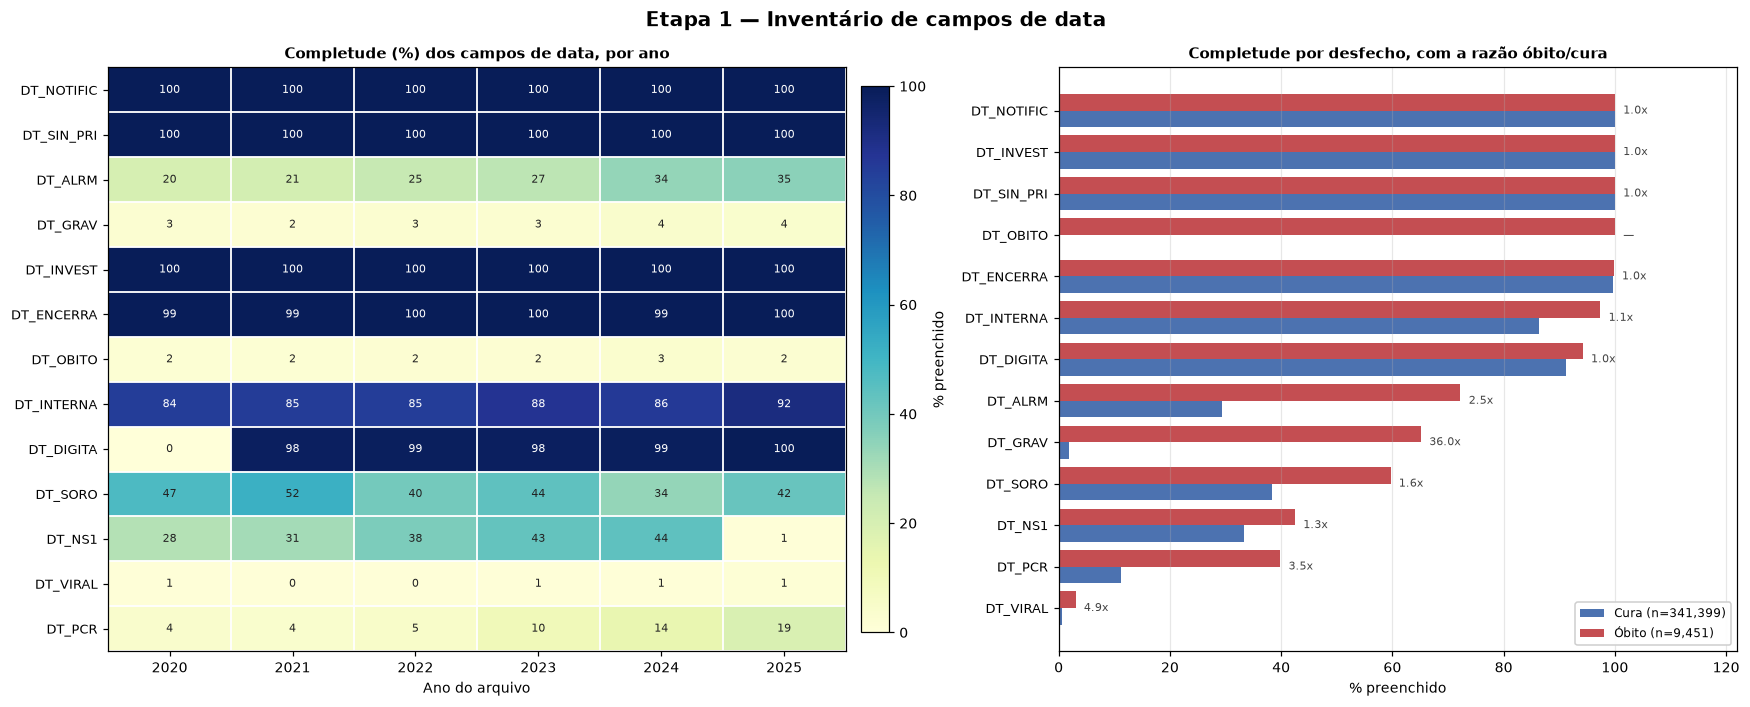

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={'width_ratios': [1.15, 1]})

# painel esquerdo: mapa de calor da completude por ano (13 linhas x 6 anos)
ax = axes[0]
matriz = (comp_ano[comp_ano['ano'] != 'TOTAL']
          .set_index('ano')[DATE_COLS_TODAS].astype(float).T)
im = ax.imshow(matriz.values, aspect='auto', cmap='YlGnBu', vmin=0, vmax=100)
ax.set_xticks(range(matriz.shape[1]))
ax.set_xticklabels(matriz.columns, fontsize=9)
ax.set_yticks(range(matriz.shape[0]))
ax.set_yticklabels(matriz.index, fontsize=8.5)
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        v = matriz.values[i, j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7.5,
                color='white' if v > 55 else '#222')
ax.set_xlabel('Ano do arquivo')
ax.set_title('Completude (%) dos campos de data, por ano', fontweight='bold', fontsize=10)
ax.set_xticks(np.arange(-0.5, matriz.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, matriz.shape[0], 1), minor=True)
ax.grid(which='minor', color='white', lw=1.2)
ax.tick_params(which='minor', length=0)
fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, label='% preenchido')

# painel direito: cura vs obito
ax = axes[1]
ordem = comp_desf.sort_values('pct_preenchido_obito')
y = np.arange(len(ordem))
ax.barh(y - 0.2, ordem['pct_preenchido_cura'], height=0.4, color=COR_CURA, label=f'Cura (n={n_cura:,})')
ax.barh(y + 0.2, ordem['pct_preenchido_obito'], height=0.4, color=COR_OBITO, label=f'Óbito (n={n_obito:,})')
ax.set_yticks(y)
ax.set_yticklabels(ordem['campo'], fontsize=8.5)
ax.set_xlabel('% preenchido')
ax.set_title('Completude por desfecho, com a razão óbito/cura', fontweight='bold', fontsize=10)
ax.set_xlim(0, 122)
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=8, loc='lower right', framealpha=0.95)
for i, (_, r) in enumerate(ordem.iterrows()):
    ax.text(max(r['pct_preenchido_cura'], r['pct_preenchido_obito']) + 1.5, i,
            r['razao_obito_cura_fmt'], va='center', fontsize=7.5, color='#444')

plt.suptitle('Etapa 1 — Inventário de campos de data', fontsize=13, fontweight='bold')
plt.tight_layout()
salvar_fig(fig, 'completude_campos_data.png')
plt.show()

### 1.2 Relatório de qualidade das datas

Duas verificações: datas fora do intervalo plausível e ordenações cronologicamente impossíveis.
A data de extração é a data de modificação dos arquivos brutos baixados em `data/raw/`.

In [9]:
mtimes = [os.path.getmtime(os.path.join(RAW_DIR, f'dengue_{a}.parquet')) for a in ANOS]
DATA_EXTRACAO = pd.Timestamp(max(mtimes), unit='s').normalize()
LIMITE_INF    = pd.Timestamp('2019-01-01')
print(f'Data de extracao (mtime mais recente em data/raw/): {DATA_EXTRACAO.date()}')
print(f'Intervalo plausivel: [{LIMITE_INF.date()}, {DATA_EXTRACAO.date()}]')

qual = []
for c in DATE_COLS_TODAS:
    s = coorte[c]
    presentes = int(s.notna().sum())
    antes = int((s < LIMITE_INF).sum())
    depois = int((s > DATA_EXTRACAO).sum())
    qual.append({
        'campo': c,
        'n_preenchido': presentes,
        'anteriores_a_2019': antes,
        'posteriores_a_extracao': depois,
        'total_implausiveis': antes + depois,
        'pct_implausiveis_entre_preenchidos': round((antes + depois) / presentes * 100, 4) if presentes else np.nan,
        'data_min': s.min(),
        'data_max': s.max(),
        'n_base': len(coorte),
    })

qual = pd.DataFrame(qual)
salvar_tab(qual, 'qualidade_datas_intervalo.csv')
display(qual)

Data de extracao (mtime mais recente em data/raw/): 2026-09-08
Intervalo plausivel: [2019-01-01, 2026-09-08]
[tabela] analysis/results_temporalidade/qualidade_datas_intervalo.csv  (13 linhas)


,campo,n_preenchido,anteriores_a_2019,posteriores_a_extracao,total_implausiveis,pct_implausiveis_entre_preenchidos,data_min,data_max,n_base
0,DT_NOTIFIC,350850,0,0,0,0.0000,2019-12-29,2026-02-23,350850
1,DT_SIN_PRI,350849,62,0,62,0.0177,1938-05-21,2026-01-03,350850
2,DT_ALRM,106988,22,27,49,0.0458,1974-04-01,2204-05-05,350850
3,DT_GRAV,12323,1,6,7,0.0568,1977-05-17,2032-05-08,350850
4,DT_INVEST,350850,3,0,3,0.0009,1963-04-22,2026-02-23,350850
5,DT_ENCERRA,349380,0,0,0,0.0000,2019-12-30,2026-03-02,350850
6,DT_OBITO,9453,0,0,0,0.0000,2019-06-01,2026-01-14,350850
7,DT_INTERNA,304243,69,0,69,0.0227,1920-05-14,2026-02-13,350850
8,DT_DIGITA,320239,2,0,2,0.0006,1800-01-01,2026-03-02,350850
9,DT_SORO,136558,0,0,0,0.0000,2019-07-25,2026-02-18,350850


Ordenações cronologicamente impossíveis entre pares de datas, e a verificação de `DT_INVEST` contra `DT_NOTIFIC`, que decide se a investigação serve como marco temporal.

In [10]:
ORDENACOES = [
    ('DT_ALRM < DT_SIN_PRI',   'DT_ALRM',   'DT_SIN_PRI'),
    ('DT_GRAV < DT_SIN_PRI',   'DT_GRAV',   'DT_SIN_PRI'),
    ('DT_INTERNA < DT_SIN_PRI','DT_INTERNA','DT_SIN_PRI'),
    ('DT_ENCERRA < DT_NOTIFIC','DT_ENCERRA','DT_NOTIFIC'),
    ('DT_OBITO < DT_INTERNA',  'DT_OBITO',  'DT_INTERNA'),
    ('DT_NOTIFIC < DT_SIN_PRI','DT_NOTIFIC','DT_SIN_PRI'),
    ('DT_DIGITA < DT_NOTIFIC', 'DT_DIGITA', 'DT_NOTIFIC'),
]

ord_rows = []
for rotulo, a, b in ORDENACOES:
    par = coorte[[a, b]].dropna()
    n_par = len(par)
    n_viol = int((par[a] < par[b]).sum())
    ord_rows.append({
        'ordenacao_impossivel': rotulo,
        'n_com_ambas_datas': n_par,
        'n_violacoes': n_viol,
        'pct_violacoes': round(n_viol / n_par * 100, 3) if n_par else np.nan,
        'n_base': len(coorte),
    })

ordenacoes = pd.DataFrame(ord_rows)
salvar_tab(ordenacoes, 'qualidade_datas_ordenacoes.csv')
display(ordenacoes)

# DT_INVEST: 100% preenchida e praticamente sempre igual a DT_NOTIFIC — na pratica e um
# preenchimento automatico, nao um registro do momento em que a investigacao ocorreu.
m_inv = coorte['DT_INVEST'].notna() & coorte['DT_NOTIFIC'].notna()
pct_inv_igual = (coorte.loc[m_inv, 'DT_INVEST'] == coorte.loc[m_inv, 'DT_NOTIFIC']).mean() * 100
print(f'\nDT_INVEST == DT_NOTIFIC em {pct_inv_igual:.2f}% dos {int(m_inv.sum()):,} registros com ambas.')
print('  DT_INVEST esta preenchida em 100% da coorte e coincide com a notificacao na quase')
print('  totalidade dos casos: e preenchimento automatico, nao a data em que a investigacao')
print('  ocorreu. Nao serve como marco temporal — ver Etapa 2.5.')

[tabela] analysis/results_temporalidade/qualidade_datas_ordenacoes.csv  (7 linhas)


,ordenacao_impossivel,n_com_ambas_datas,n_violacoes,pct_violacoes,n_base
0,DT_ALRM < DT_SIN_PRI,106988,2534,2.368,350850
1,DT_GRAV < DT_SIN_PRI,12323,263,2.134,350850
2,DT_INTERNA < DT_SIN_PRI,304242,6931,2.278,350850
3,DT_ENCERRA < DT_NOTIFIC,349380,31,0.009,350850
4,DT_OBITO < DT_INTERNA,9205,43,0.467,350850
5,DT_NOTIFIC < DT_SIN_PRI,350849,0,0.000,350850
6,DT_DIGITA < DT_NOTIFIC,320239,11,0.003,350850



DT_INVEST == DT_NOTIFIC em 93.96% dos 350,850 registros com ambas.
  DT_INVEST esta preenchida em 100% da coorte e coincide com a notificacao na quase
  totalidade dos casos: e preenchimento automatico, nao a data em que a investigacao
  ocorreu. Nao serve como marco temporal — ver Etapa 2.5.


### 1.3 Ponto de decisão sobre `DT_ALRM` e `DT_GRAV`

A completude dessas duas datas define se as etapas 2.2 a 2.4 têm base suficiente. O resultado é
avaliado explicitamente abaixo, e a decisão é registrada na narrativa em vez de ficar implícita.

In [11]:
p_alrm_geral = coorte['DT_ALRM'].notna().mean() * 100
p_grav_geral = coorte['DT_GRAV'].notna().mean() * 100
p_alrm_obito = coorte.loc[coorte['obito'], 'DT_ALRM'].notna().mean() * 100
p_grav_obito = coorte.loc[coorte['obito'], 'DT_GRAV'].notna().mean() * 100

print(f'DT_ALRM — coorte: {p_alrm_geral:.1f}% ({int(coorte["DT_ALRM"].notna().sum()):,}) | '
      f'obitos: {p_alrm_obito:.1f}% ({int(coorte.loc[coorte["obito"], "DT_ALRM"].notna().sum()):,})')
print(f'DT_GRAV — coorte: {p_grav_geral:.1f}% ({int(coorte["DT_GRAV"].notna().sum()):,}) | '
      f'obitos: {p_grav_obito:.1f}% ({int(coorte.loc[coorte["obito"], "DT_GRAV"].notna().sum()):,})')
print()

LIMIAR = 10.0
if p_alrm_obito < LIMIAR and p_grav_obito < LIMIAR:
    print(f'[DECISAO] Completude abaixo de {LIMIAR:.0f}% entre obitos nas duas datas. '
          'As etapas 2.2-2.4 ficam com base fraca; 2.4-2.7 passam a ser a evidencia principal.')
else:
    print(f'[DECISAO] Completude entre obitos e suficiente ({p_alrm_obito:.1f}% e {p_grav_obito:.1f}%, '
          f'ambas acima de {LIMIAR:.0f}%). As etapas 2.2-2.4 sao interpretaveis sobre o subconjunto datado, '
          'e o proprio diferencial de completude entre desfechos e resultado (Etapa 2.6).')
    print('    Ressalva que vale para toda a Etapa 2: as analises de defasagem se restringem aos '
          'registros com a data preenchida, que sao um subconjunto seletivo — casos em que o sinal '
          'foi de fato registrado. O N de base vai em cada tabela.')

DT_ALRM — coorte: 30.5% (106,988) | obitos: 72.2% (6,826)
DT_GRAV — coorte: 3.5% (12,323) | obitos: 65.1% (6,155)

[DECISAO] Completude entre obitos e suficiente (72.2% e 65.1%, ambas acima de 10%). As etapas 2.2-2.4 sao interpretaveis sobre o subconjunto datado, e o proprio diferencial de completude entre desfechos e resultado (Etapa 2.6).
    Ressalva que vale para toda a Etapa 2: as analises de defasagem se restringem aos registros com a data preenchida, que sao um subconjunto seletivo — casos em que o sinal foi de fato registrado. O N de base vai em cada tabela.


---

## Etapa 2 — Perguntas quantitativas centrais

Funções auxiliares comuns às sub-etapas: descrição de defasagem em dias e faixas de defasagem.
Nenhuma imputação; toda tabela carrega o N de base.

In [12]:
FAIXAS = [
    ('<= -1 (antes)', lambda s: s <= -1),
    ('0 (mesmo dia)', lambda s: s == 0),
    ('1 a 2',         lambda s: s.between(1, 2)),
    ('3 a 7',         lambda s: s.between(3, 7)),
    ('> 7',           lambda s: s > 7),
]


def descrever_defasagem(serie_dias: pd.Series, rotulo: str, n_base: int) -> dict:
    s = serie_dias.dropna()
    if s.empty:
        return {'comparacao': rotulo, 'n_com_ambas_datas': 0, 'n_base': n_base}
    d = {
        'comparacao': rotulo,
        'n_com_ambas_datas': len(s),
        'pct_do_n_base': round(len(s) / n_base * 100, 2) if n_base else np.nan,
        'mediana': float(s.median()),
        'p25': float(s.quantile(0.25)),
        'p75': float(s.quantile(0.75)),
        'p90': float(s.quantile(0.90)),
        'p95': float(s.quantile(0.95)),
        'media': round(float(s.mean()), 2),
        'n_base': n_base,
    }
    for nome, cond in FAIXAS:
        d[f'pct_{nome}'] = round(cond(s).mean() * 100, 2)
    d['pct_<= 0'] = round((s <= 0).mean() * 100, 2)
    d['pct_> 0'] = round((s > 0).mean() * 100, 2)
    return d


def dias(df_, a, b):
    return (df_[a] - df_[b]).dt.days


def por_desfecho(df_, a, b, rotulo):
    saida = []
    for nome, sub in [('Total', df_), ('Cura', df_[~df_['obito']]), ('Óbito', df_[df_['obito']])]:
        linha = descrever_defasagem(dias(sub, a, b), rotulo, len(sub))
        linha['desfecho'] = nome
        saida.append(linha)
    return saida


def ordenar_cols(df_):
    primeiras = ['comparacao', 'desfecho', 'n_base', 'n_com_ambas_datas', 'pct_do_n_base']
    resto = [c for c in df_.columns if c not in primeiras]
    return df_[[c for c in primeiras if c in df_.columns] + resto]


print('Auxiliares prontos.')

Auxiliares prontos.


### 2.1 Consistência entre a data e os campos que ela data

Responde diretamente ao pressuposto de que `ALRM_*` e `GRAV_*` só são preenchidos
quando o sinal está clinicamente presente. Duas direções: entre os registros com pelo menos um
sinal marcado como presente, quantos têm a data correspondente; e o inverso.

In [13]:
tem_alrm = (coorte[ALRM_COLS] == 1).any(axis=1)
tem_grav = (coorte[GRAV_COLS] == 1).any(axis=1)
tem_dt_alrm = coorte['DT_ALRM'].notna()
tem_dt_grav = coorte['DT_GRAV'].notna()

def consistencia(nome_bloco, sinal, data, nome_data):
    linhas = []
    for desf, m in [('Total', pd.Series(True, index=coorte.index)),
                    ('Cura', ~coorte['obito']), ('Óbito', coorte['obito'])]:
        s, d = sinal[m], data[m]
        linhas.append({
            'bloco': nome_bloco,
            'desfecho': desf,
            'n_base': int(m.sum()),
            'n_com_algum_sinal_presente': int(s.sum()),
            f'pct_com_{nome_data}_entre_sinal_presente': round(d[s].mean() * 100, 2) if s.sum() else np.nan,
            f'n_com_{nome_data}': int(d.sum()),
            f'pct_com_algum_sinal_entre_{nome_data}': round(s[d].mean() * 100, 2) if d.sum() else np.nan,
            f'n_{nome_data}_sem_nenhum_sinal': int((d & ~s).sum()),
            f'n_sinal_sem_{nome_data}': int((s & ~d).sum()),
        })
    return pd.DataFrame(linhas)

cons_alrm = consistencia('Sinais de alarme (ALRM_*)', tem_alrm, tem_dt_alrm, 'DT_ALRM')
cons_grav = consistencia('Sinais de gravidade (GRAV_*)', tem_grav, tem_dt_grav, 'DT_GRAV')

salvar_tab(cons_alrm, 'consistencia_alrm_dt_alrm.csv')
salvar_tab(cons_grav, 'consistencia_grav_dt_grav.csv')
display(cons_alrm)
display(cons_grav)

[tabela] analysis/results_temporalidade/consistencia_alrm_dt_alrm.csv  (3 linhas)
[tabela] analysis/results_temporalidade/consistencia_grav_dt_grav.csv  (3 linhas)


,bloco,desfecho,n_base,n_com_algum_sinal_presente,pct_com_DT_ALRM_entre_sinal_presente,n_com_DT_ALRM,pct_com_algum_sinal_entre_DT_ALRM,n_DT_ALRM_sem_nenhum_sinal,n_sinal_sem_DT_ALRM
0,Sinais de alarme (ALRM_*),Total,350850,106783,99.03,106988,98.84,1237,1032
1,Sinais de alarme (ALRM_*),Cura,341399,99847,99.20,100162,98.89,1115,800
2,Sinais de alarme (ALRM_*),Óbito,9451,6936,96.66,6826,98.21,122,232


,bloco,desfecho,n_base,n_com_algum_sinal_presente,pct_com_DT_GRAV_entre_sinal_presente,n_com_DT_GRAV,pct_com_algum_sinal_entre_DT_GRAV,n_DT_GRAV_sem_nenhum_sinal,n_sinal_sem_DT_GRAV
0,Sinais de gravidade (GRAV_*),Total,350850,11793,98.95,12323,94.69,654,124
1,Sinais de gravidade (GRAV_*),Cura,341399,5777,98.17,6168,91.94,497,106
2,Sinais de gravidade (GRAV_*),Óbito,9451,6016,99.70,6155,97.45,157,18


### 2.2 Defasagem entre a notificação e o registro do sinal

`DT_ALRM − DT_NOTIFIC` e `DT_GRAV − DT_NOTIFIC`, em dias, por desfecho. Valores positivos
indicam sinal datado **depois** da notificação — informação que não estava disponível no momento
em que a ficha foi aberta.

In [14]:
rows = []
rows += por_desfecho(coorte, 'DT_ALRM', 'DT_NOTIFIC', 'DT_ALRM - DT_NOTIFIC')
rows += por_desfecho(coorte, 'DT_GRAV', 'DT_NOTIFIC', 'DT_GRAV - DT_NOTIFIC')
defas_notif = ordenar_cols(pd.DataFrame(rows))
salvar_tab(defas_notif, 'defasagem_sinal_vs_notificacao.csv')
display(defas_notif)

[tabela] analysis/results_temporalidade/defasagem_sinal_vs_notificacao.csv  (6 linhas)


,comparacao,desfecho,n_base,n_com_ambas_datas,pct_do_n_base,mediana,p25,p75,p90,p95,media,pct_<= -1 (antes),pct_0 (mesmo dia),pct_1 a 2,pct_3 a 7,pct_> 7,pct_<= 0,pct_> 0
0,DT_ALRM - DT_NOTIFIC,Total,350850,106988,30.49,-1.0,-3.0,0.0,3.0,5.0,4.16,55.68,25.25,8.19,8.70,2.18,80.92,19.08
1,DT_ALRM - DT_NOTIFIC,Cura,341399,100162,29.34,-1.0,-3.0,0.0,3.0,4.0,4.08,55.78,25.34,8.11,8.72,2.05,81.12,18.88
2,DT_ALRM - DT_NOTIFIC,Óbito,9451,6826,72.23,-1.0,-3.0,0.0,3.0,6.0,5.29,54.13,23.91,9.38,8.48,4.10,78.04,21.96
3,DT_GRAV - DT_NOTIFIC,Total,350850,12323,3.51,0.0,-3.0,1.0,4.0,8.0,-1.80,49.35,24.24,10.44,10.40,5.57,73.59,26.41
4,DT_GRAV - DT_NOTIFIC,Cura,341399,6168,1.81,-1.0,-3.0,0.0,2.0,5.0,-4.76,57.04,25.70,7.30,7.44,2.53,82.73,17.27
5,DT_GRAV - DT_NOTIFIC,Óbito,9451,6155,65.13,0.0,-2.0,2.0,7.0,14.0,1.16,41.64,22.78,13.60,13.37,8.61,64.42,35.58


### 3.3 Registro do sinal em relação à internação

`DT_ALRM − DT_INTERNA` e `DT_GRAV − DT_INTERNA`.
A proporção com defasagem maior que zero é a medida direta de informação capturada durante o acompanhamento hospitalar, e não na apresentação inicial.
Fica registrado também quantos casos da coorte são internados sem `DT_INTERNA`, para os quais essa ancoragem não existe.

In [15]:
sem_dt_interna = int(coorte['DT_INTERNA'].isna().sum())
print(f'Internados (HOSPITALIZ == 1) sem DT_INTERNA: {sem_dt_interna:,} '
      f'({sem_dt_interna / len(coorte) * 100:.2f}% da coorte)')
print(f'  entre curas:  {int(coorte.loc[~coorte["obito"], "DT_INTERNA"].isna().sum()):,} '
      f'({coorte.loc[~coorte["obito"], "DT_INTERNA"].isna().mean() * 100:.2f}%)')
print(f'  entre obitos: {int(coorte.loc[coorte["obito"], "DT_INTERNA"].isna().sum()):,} '
      f'({coorte.loc[coorte["obito"], "DT_INTERNA"].isna().mean() * 100:.2f}%)')
print()

rows = []
rows += por_desfecho(coorte, 'DT_ALRM', 'DT_INTERNA', 'DT_ALRM - DT_INTERNA')
rows += por_desfecho(coorte, 'DT_GRAV', 'DT_INTERNA', 'DT_GRAV - DT_INTERNA')
defas_int = ordenar_cols(pd.DataFrame(rows))
salvar_tab(defas_int, 'defasagem_sinal_vs_internacao.csv')
display(defas_int)

Internados (HOSPITALIZ == 1) sem DT_INTERNA: 46,607 (13.28% da coorte)
  entre curas:  46,359 (13.58%)
  entre obitos: 248 (2.62%)



[tabela] analysis/results_temporalidade/defasagem_sinal_vs_internacao.csv  (6 linhas)


,comparacao,desfecho,n_base,n_com_ambas_datas,pct_do_n_base,mediana,p25,p75,p90,p95,media,pct_<= -1 (antes),pct_0 (mesmo dia),pct_1 a 2,pct_3 a 7,pct_> 7,pct_<= 0,pct_> 0
0,DT_ALRM - DT_INTERNA,Total,350850,104612,29.82,0.0,-1.0,0.0,1.0,2.0,6.76,31.64,58.00,5.82,2.29,2.24,89.65,10.35
1,DT_ALRM - DT_INTERNA,Cura,341399,97917,28.68,0.0,-1.0,0.0,0.0,2.0,6.56,31.87,58.43,5.52,2.08,2.10,90.31,9.69
2,DT_ALRM - DT_INTERNA,Óbito,9451,6695,70.84,0.0,-1.0,0.0,2.0,6.0,9.68,28.24,51.73,10.20,5.50,4.33,79.97,20.03
3,DT_GRAV - DT_INTERNA,Total,350850,12067,3.44,0.0,0.0,1.0,4.0,9.0,2.39,21.17,50.73,14.24,7.97,5.89,71.90,28.10
4,DT_GRAV - DT_INTERNA,Cura,341399,6046,1.77,0.0,-1.0,0.0,1.0,4.0,-0.62,28.93,54.22,10.21,4.22,2.43,83.15,16.85
5,DT_GRAV - DT_INTERNA,Óbito,9451,6021,63.71,0.0,0.0,2.0,7.0,15.0,5.42,13.39,47.22,18.29,11.74,9.37,60.60,39.40


Figuras das defasagens em relação à notificação e à internação, por bloco e por desfecho.

[figura] analysis/plots/temporalidade/defasagem_sinal_notificacao_internacao.png


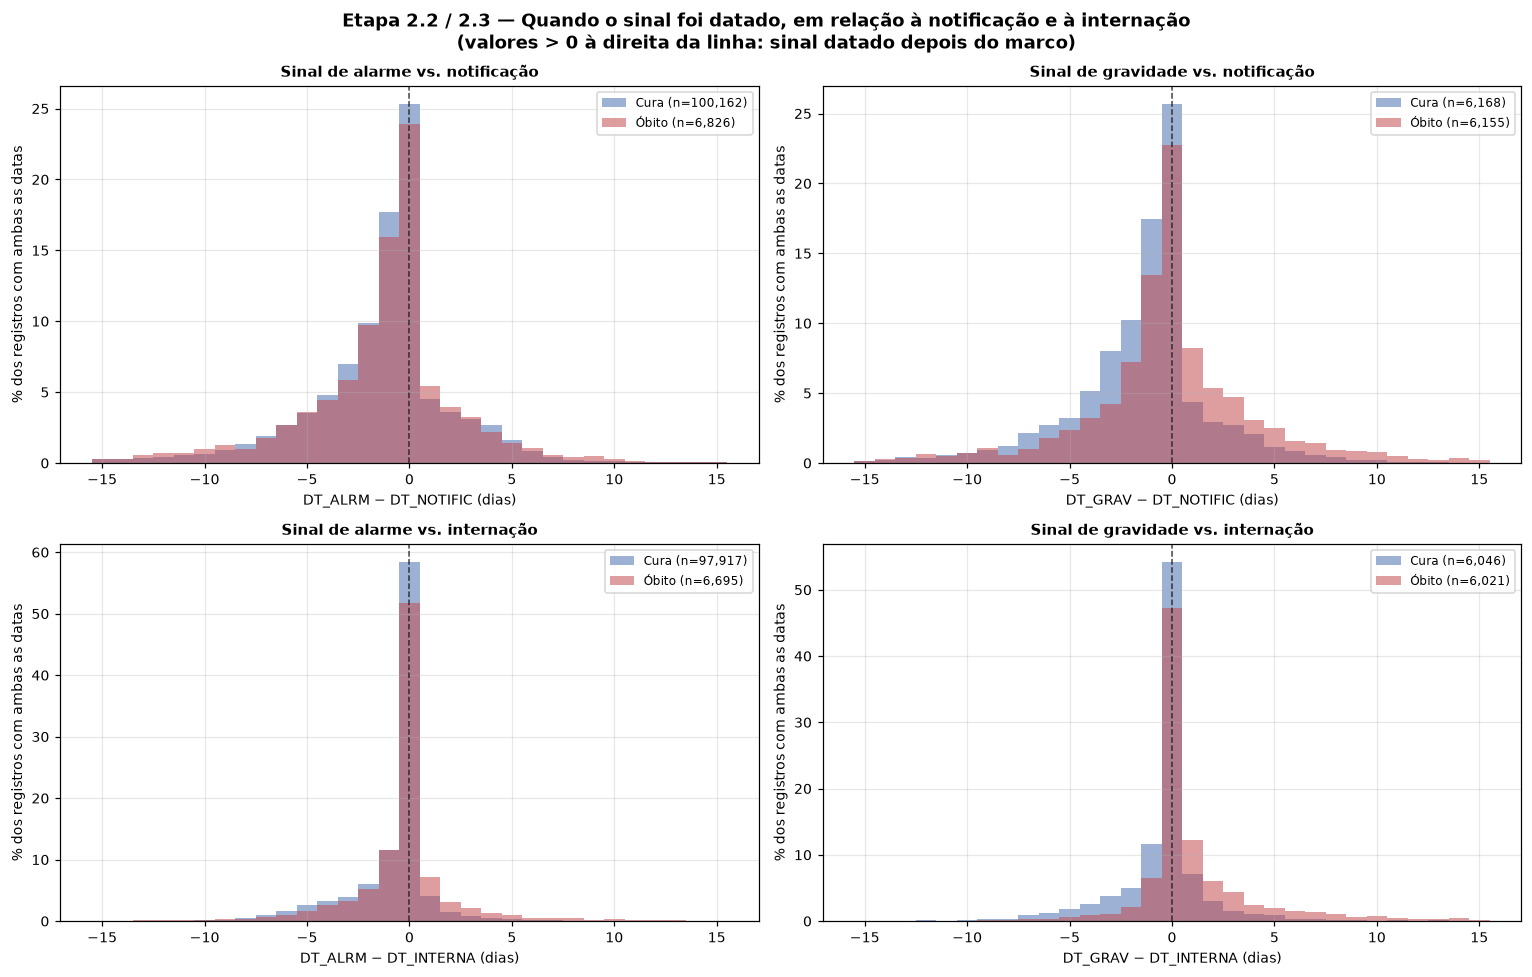

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
combos = [
    ('DT_ALRM', 'DT_NOTIFIC', 'Sinal de alarme vs. notificação'),
    ('DT_GRAV', 'DT_NOTIFIC', 'Sinal de gravidade vs. notificação'),
    ('DT_ALRM', 'DT_INTERNA', 'Sinal de alarme vs. internação'),
    ('DT_GRAV', 'DT_INTERNA', 'Sinal de gravidade vs. internação'),
]
bins = np.arange(-15.5, 16.5, 1)

for ax, (a, b, titulo) in zip(axes.ravel(), combos):
    for rotulo, sub, cor in [('Cura', coorte[~coorte['obito']], COR_CURA),
                             ('Óbito', coorte[coorte['obito']], COR_OBITO)]:
        s = dias(sub, a, b).dropna()
        s = s[(s >= -15) & (s <= 15)]
        if s.empty:
            continue
        pesos = np.ones(len(s)) / len(dias(sub, a, b).dropna()) * 100
        ax.hist(s, bins=bins, weights=pesos, alpha=0.55, color=cor,
                label=f'{rotulo} (n={len(dias(sub, a, b).dropna()):,})')
    ax.axvline(0, color='k', ls='--', lw=1, alpha=0.7)
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.set_xlabel(f'{a} − {b} (dias)')
    ax.set_ylabel('% dos registros com ambas as datas')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Etapa 2.2 / 2.3 — Quando o sinal foi datado, em relação à notificação e à internação\n'
             '(valores > 0 à direita da linha: sinal datado depois do marco)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
salvar_fig(fig, 'defasagem_sinal_notificacao_internacao.png')
plt.show()

### 2.4 Registro do sinal em relação ao óbito

Restrito a `EVOLUCAO == 2` com `DT_OBITO` preenchida. `DT_OBITO − DT_ALRM` e
`DT_OBITO − DT_GRAV`: valores **≤ 0** significam sinal datado no mesmo dia do óbito ou depois
dele. É o indicador mais direto de vazamento temporal disponível nos dados.

In [17]:
obitos = coorte[coorte['obito'] & coorte['DT_OBITO'].notna()].copy()
print(f'Obitos com DT_OBITO preenchida: {len(obitos):,} de {int(coorte["obito"].sum()):,} '
      f'({len(obitos) / int(coorte["obito"].sum()) * 100:.2f}%)')

rows = []
for c, rotulo in [('DT_ALRM', 'DT_OBITO - DT_ALRM'), ('DT_GRAV', 'DT_OBITO - DT_GRAV')]:
    s = (obitos['DT_OBITO'] - obitos[c]).dt.days.dropna()
    linha = descrever_defasagem(s, rotulo, len(obitos))
    linha['desfecho'] = 'Óbito'
    linha['pct_sinal_no_dia_do_obito_ou_depois'] = round((s <= 0).mean() * 100, 2) if len(s) else np.nan
    linha['n_sinal_no_dia_do_obito_ou_depois'] = int((s <= 0).sum())
    linha['pct_sinal_no_mesmo_dia'] = round((s == 0).mean() * 100, 2) if len(s) else np.nan
    linha['pct_sinal_depois_do_obito'] = round((s < 0).mean() * 100, 2) if len(s) else np.nan
    linha['n_sinal_depois_do_obito'] = int((s < 0).sum())
    rows.append(linha)

vs_obito = ordenar_cols(pd.DataFrame(rows))
salvar_tab(vs_obito, 'defasagem_sinal_vs_obito.csv')
display(vs_obito)

Obitos com DT_OBITO preenchida: 9,451 de 9,451 (100.00%)
[tabela] analysis/results_temporalidade/defasagem_sinal_vs_obito.csv  (2 linhas)


,comparacao,desfecho,n_base,n_com_ambas_datas,pct_do_n_base,mediana,p25,p75,p90,p95,...,pct_1 a 2,pct_3 a 7,pct_> 7,pct_<= 0,pct_> 0,pct_sinal_no_dia_do_obito_ou_depois,n_sinal_no_dia_do_obito_ou_depois,pct_sinal_no_mesmo_dia,pct_sinal_depois_do_obito,n_sinal_depois_do_obito
0,DT_OBITO - DT_ALRM,Óbito,9451,6826,72.23,3.0,1.0,8.0,17.0,26.0,...,30.31,28.96,27.13,13.60,86.40,13.60,928,11.53,2.07,141
1,DT_OBITO - DT_GRAV,Óbito,9451,6155,65.13,2.0,0.0,6.0,13.0,22.0,...,32.67,21.51,19.09,26.73,73.27,26.73,1645,23.75,2.97,183


Figura da defasagem entre o óbito e o registro do sinal, com o zero marcado: à esquerda dele estão os registros datados no dia do óbito ou depois.

[figura] analysis/plots/temporalidade/sinal_vs_obito.png


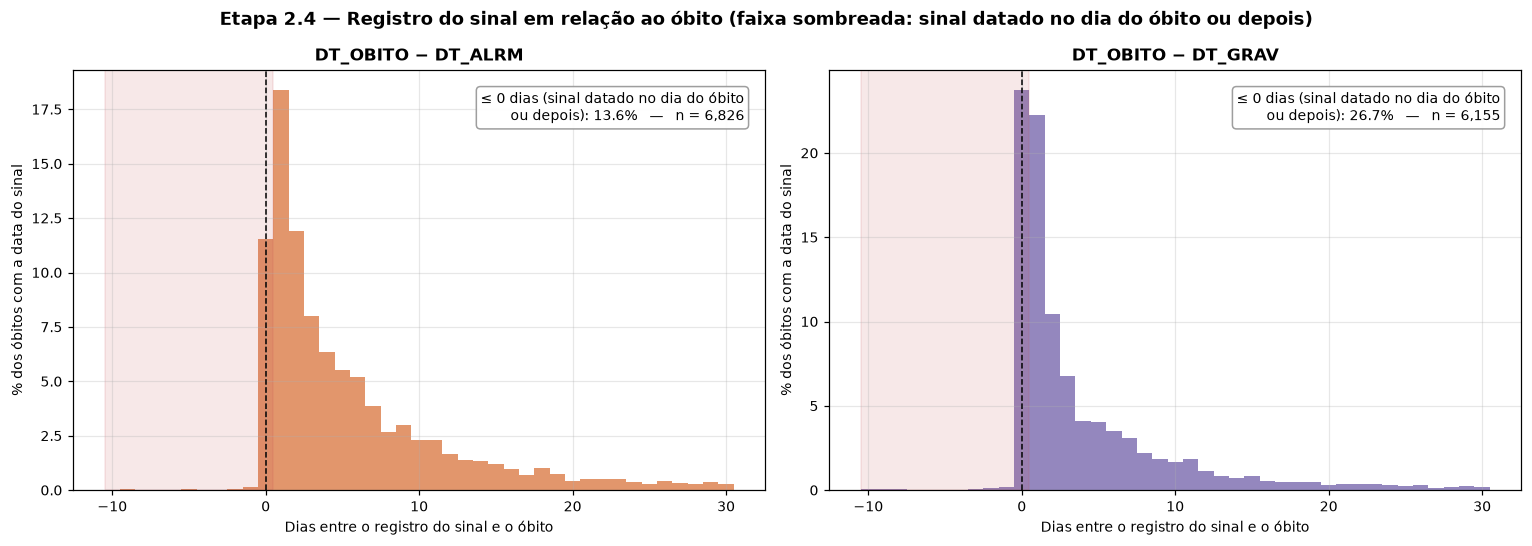

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (c, cor, titulo) in zip(axes, [
        ('DT_ALRM', COR_ALRM, 'DT_OBITO − DT_ALRM'),
        ('DT_GRAV', COR_GRAV, 'DT_OBITO − DT_GRAV')]):
    s_full = (obitos['DT_OBITO'] - obitos[c]).dt.days.dropna()
    s = s_full[(s_full >= -10) & (s_full <= 30)]
    pesos = np.ones(len(s)) / len(s_full) * 100
    ax.hist(s, bins=np.arange(-10.5, 31.5, 1), weights=pesos, color=cor, alpha=0.85)
    ax.axvspan(-10.5, 0.5, color=COR_OBITO, alpha=0.13)
    ax.axvline(0, color='k', ls='--', lw=1)
    pct = (s_full <= 0).mean() * 100
    ax.text(0.97, 0.95, f'≤ 0 dias (sinal datado no dia do óbito\nou depois): {pct:.1f}%   —   n = {len(s_full):,}',
            transform=ax.transAxes, va='top', ha='right', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', ec='#999', alpha=0.95))
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Dias entre o registro do sinal e o óbito')
    ax.set_ylabel('% dos óbitos com a data do sinal')
    ax.grid(alpha=0.3)

plt.suptitle('Etapa 2.4 — Registro do sinal em relação ao óbito (faixa sombreada: sinal datado no dia do óbito ou depois)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
salvar_fig(fig, 'sinal_vs_obito.png')
plt.show()

### 2.5 Digitação, investigação e encerramento

`DT_DIGITA − DT_NOTIFIC`, `DT_INVEST − DT_NOTIFIC` e `DT_ENCERRA − DT_NOTIFIC`, por desfecho.
Defasagem sistematicamente maior em óbitos indica que a ficha é consolidada na investigação, e não
na notificação.

In [19]:
rows = []
for a, rotulo in [('DT_DIGITA', 'DT_DIGITA - DT_NOTIFIC'),
                  ('DT_INVEST', 'DT_INVEST - DT_NOTIFIC'),
                  ('DT_ENCERRA', 'DT_ENCERRA - DT_NOTIFIC')]:
    rows += por_desfecho(coorte, a, 'DT_NOTIFIC', rotulo)
fluxo = ordenar_cols(pd.DataFrame(rows))
salvar_tab(fluxo, 'defasagem_fluxo_administrativo.csv')
display(fluxo)

[tabela] analysis/results_temporalidade/defasagem_fluxo_administrativo.csv  (9 linhas)


,comparacao,desfecho,n_base,n_com_ambas_datas,pct_do_n_base,mediana,p25,p75,p90,p95,media,pct_<= -1 (antes),pct_0 (mesmo dia),pct_1 a 2,pct_3 a 7,pct_> 7,pct_<= 0,pct_> 0
0,DT_DIGITA - DT_NOTIFIC,Total,350850,320239,91.28,4.0,1.0,12.0,31.0,55.0,12.10,0.00,21.56,20.28,24.17,33.99,21.56,78.44
1,DT_DIGITA - DT_NOTIFIC,Cura,341399,311334,91.19,4.0,1.0,12.0,31.0,55.0,12.74,0.00,21.45,20.17,24.15,34.23,21.45,78.55
2,DT_DIGITA - DT_NOTIFIC,Óbito,9451,8905,94.22,3.0,0.0,8.0,20.0,34.0,-9.99,0.02,25.50,24.02,25.05,25.40,25.52,74.48
3,DT_INVEST - DT_NOTIFIC,Total,350850,350850,100.00,0.0,0.0,0.0,0.0,1.0,0.57,0.72,93.96,1.99,1.53,1.81,94.68,5.32
4,DT_INVEST - DT_NOTIFIC,Cura,341399,341399,100.00,0.0,0.0,0.0,0.0,1.0,0.57,0.73,93.98,1.98,1.52,1.80,94.70,5.30
5,DT_INVEST - DT_NOTIFIC,Óbito,9451,9451,100.00,0.0,0.0,0.0,0.0,1.0,0.75,0.35,93.29,2.48,1.89,1.99,93.64,6.36
6,DT_ENCERRA - DT_NOTIFIC,Total,350850,349380,99.58,13.0,5.0,32.0,61.0,80.0,25.45,0.01,9.12,7.30,18.55,65.02,9.12,90.88
7,DT_ENCERRA - DT_NOTIFIC,Cura,341399,339950,99.58,13.0,5.0,31.0,61.0,77.0,24.93,0.01,9.26,7.41,18.82,64.50,9.27,90.73
8,DT_ENCERRA - DT_NOTIFIC,Óbito,9451,9430,99.78,29.0,13.0,55.0,95.0,151.0,43.98,0.01,3.74,3.43,8.88,83.94,3.75,96.25


Figura das três defasagens administrativas por desfecho, na mesma escala.

[figura] analysis/plots/temporalidade/fluxo_administrativo_por_desfecho.png


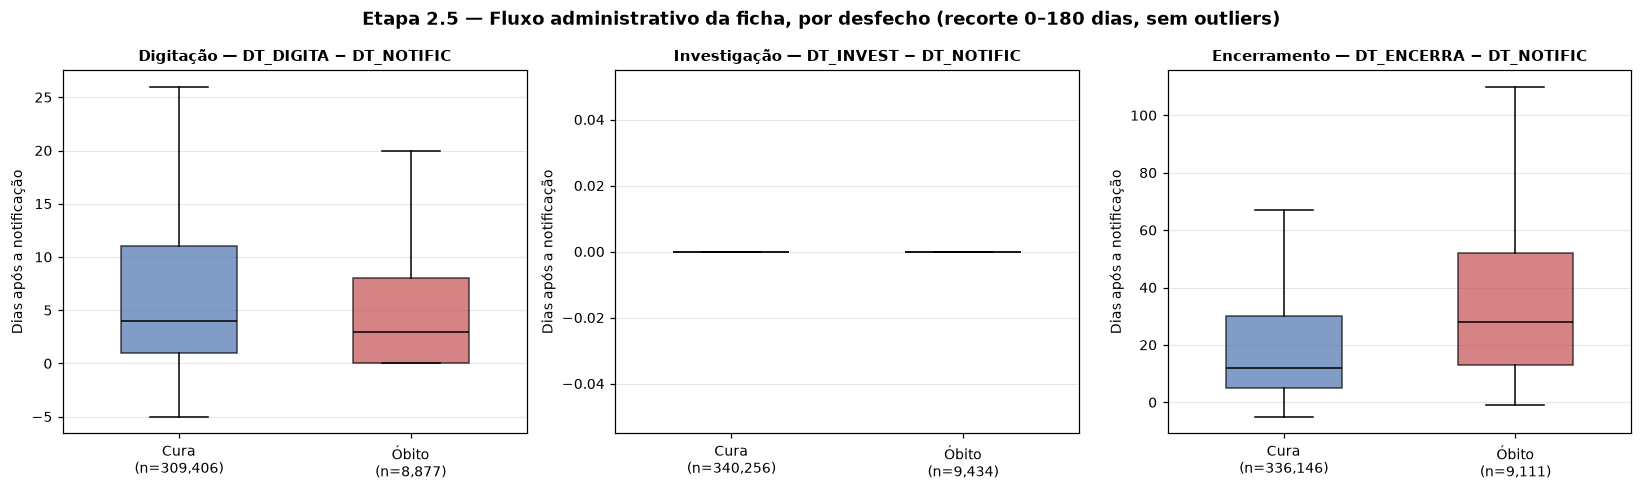

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (a, titulo) in zip(axes, [('DT_DIGITA', 'Digitação'),
                                  ('DT_INVEST', 'Investigação'),
                                  ('DT_ENCERRA', 'Encerramento')]):
    dados, rotulos, cores = [], [], []
    for rotulo, sub, cor in [('Cura', coorte[~coorte['obito']], COR_CURA),
                             ('Óbito', coorte[coorte['obito']], COR_OBITO)]:
        s = dias(sub, a, 'DT_NOTIFIC').dropna()
        s = s[(s >= -5) & (s <= 180)]
        dados.append(s.values)
        rotulos.append(f'{rotulo}\n(n={len(s):,})')
        cores.append(cor)
    bp = ax.boxplot(dados, tick_labels=rotulos, showfliers=False, patch_artist=True, widths=0.5)
    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    for mediana in bp['medians']:
        mediana.set_color('k')
    ax.set_title(f'{titulo} — {a} − DT_NOTIFIC', fontweight='bold', fontsize=10)
    ax.set_ylabel('Dias após a notificação')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Etapa 2.5 — Fluxo administrativo da ficha, por desfecho (recorte 0–180 dias, sem outliers)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
salvar_fig(fig, 'fluxo_administrativo_por_desfecho.png')
plt.show()

### 2.6 Completude condicionada ao desfecho, campo a campo

Para cada um dos 9 sinais de alarme e 15 critérios de gravidade: % ausente em óbitos contra %
ausente em curas, com a razão entre as duas. Se o preenchimento ocorresse apenas na notificação,
a completude não deveria depender de um desfecho que ainda não ocorreu. Esta é a evidência que
**não depende** de `DT_ALRM` / `DT_GRAV` estarem preenchidas.

In [21]:
rows = []
for c in ALRM_COLS + GRAV_COLS:
    aus_obito = coorte.loc[coorte['obito'], c].isna().mean() * 100
    aus_cura  = coorte.loc[~coorte['obito'], c].isna().mean() * 100
    rows.append({
        'campo': c,
        'bloco': 'alarme' if c.startswith('ALRM_') else 'gravidade',
        'pct_ausente_obito': round(aus_obito, 2),
        'pct_ausente_cura': round(aus_cura, 2),
        'razao_ausencia_obito_cura': round(aus_obito / aus_cura, 3) if aus_cura else np.nan,
        'diferenca_pp': round(aus_obito - aus_cura, 2),
        'pct_presente_positivo_obito': round((coorte.loc[coorte['obito'], c] == 1).mean() * 100, 2),
        'pct_presente_positivo_cura': round((coorte.loc[~coorte['obito'], c] == 1).mean() * 100, 2),
        'n_base_obito': n_obito,
        'n_base_cura': n_cura,
    })

ausencia = pd.DataFrame(rows).sort_values('razao_ausencia_obito_cura')
salvar_tab(ausencia, 'ausencia_sinais_por_desfecho.csv')
display(ausencia)

[tabela] analysis/results_temporalidade/ausencia_sinais_por_desfecho.csv  (24 linhas)


,campo,bloco,pct_ausente_obito,pct_ausente_cura,razao_ausencia_obito_cura,diferenca_pp,pct_presente_positivo_obito,pct_presente_positivo_cura,n_base_obito,n_base_cura
1,ALRM_PLAQ,alarme,24.84,70.38,0.353,-45.54,49.66,20.28,9451,341399
5,ALRM_ABDOM,alarme,25.01,70.43,0.355,-45.42,31.74,11.77,9451,341399
3,ALRM_SANG,alarme,25.11,70.46,0.356,-45.35,22.59,7.32,9451,341399
0,ALRM_HIPOT,alarme,25.09,70.46,0.356,-45.37,38.72,5.05,9451,341399
12,GRAV_INSUF,gravidade,34.98,98.15,0.356,-63.17,21.30,0.23,9451,341399
13,GRAV_TAQUI,gravidade,34.96,98.15,0.356,-63.19,30.77,0.41,9451,341399
14,GRAV_EXTRE,gravidade,34.92,98.15,0.356,-63.24,34.97,0.25,9451,341399
9,GRAV_PULSO,gravidade,34.93,98.14,0.356,-63.22,24.69,0.09,9451,341399
15,GRAV_HIPOT,gravidade,34.93,98.15,0.356,-63.22,27.18,0.18,9451,341399
22,GRAV_CONSC,gravidade,34.92,98.16,0.356,-63.24,35.48,0.30,9451,341399


Figura da ausência por campo, com óbitos e curas lado a lado, ordenada pela ausência nas curas.

[figura] analysis/plots/temporalidade/ausencia_sinais_por_desfecho.png


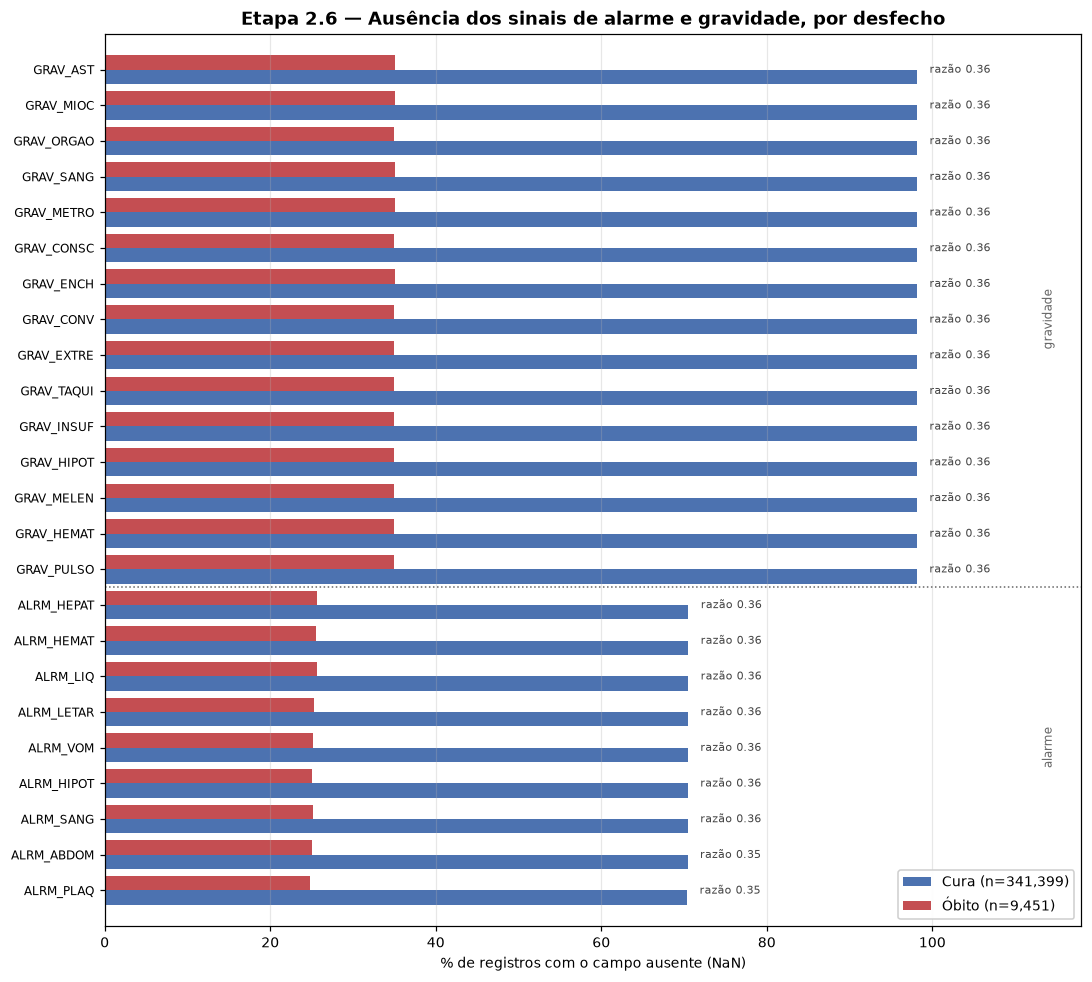

In [22]:
ordem = ausencia.sort_values('pct_ausente_cura')
y = np.arange(len(ordem))
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(y - 0.2, ordem['pct_ausente_cura'], height=0.4, color=COR_CURA, label=f'Cura (n={n_cura:,})')
ax.barh(y + 0.2, ordem['pct_ausente_obito'], height=0.4, color=COR_OBITO, label=f'Óbito (n={n_obito:,})')
ax.set_yticks(y)
ax.set_yticklabels([f"{r['campo']}" for _, r in ordem.iterrows()], fontsize=8)
ax.set_xlabel('% de registros com o campo ausente (NaN)')
ax.set_xlim(0, 118)
ax.set_ylim(-1, len(ordem))
ax.grid(axis='x', alpha=0.3)

# linha separando o bloco de alarme do bloco de gravidade
troca = ordem['bloco'].ne(ordem['bloco'].shift()).to_numpy().nonzero()[0]
for t in troca[1:]:
    ax.axhline(t - 0.5, color='#666', lw=1, ls=':')
ax.text(114, ordem['bloco'].eq('alarme').to_numpy().nonzero()[0].mean(), 'alarme',
        rotation=90, va='center', ha='center', fontsize=8, color='#666')
ax.text(114, ordem['bloco'].eq('gravidade').to_numpy().nonzero()[0].mean(), 'gravidade',
        rotation=90, va='center', ha='center', fontsize=8, color='#666')

ax.legend(fontsize=9, loc='lower right', framealpha=0.95)
for i, (_, r) in enumerate(ordem.iterrows()):
    ax.text(max(r['pct_ausente_cura'], r['pct_ausente_obito']) + 1.5, i,
            f"razão {r['razao_ausencia_obito_cura']:.2f}", va='center', fontsize=7, color='#444')
ax.set_title('Etapa 2.6 — Ausência dos sinais de alarme e gravidade, por desfecho',
             fontweight='bold', fontsize=12)
plt.tight_layout()
salvar_fig(fig, 'ausencia_sinais_por_desfecho.png')
plt.show()

### 3.7 Duração da internação e completude dos sinais

Testa a hipótese concorrente de que óbitos rápidos teriam mais ausências por falta de tempo de documentação.
A duração vem de `DT_OBITO − DT_INTERNA` e, quando `DT_INTERNA` está ausente, de `DT_OBITO − DT_SIN_PRI`, com a fonte usada em cada caso registrada na tabela.

In [23]:
ob = obitos.copy()
ob['dias_ate_obito'] = (ob['DT_OBITO'] - ob['DT_INTERNA']).dt.days
ob['fonte_duracao'] = np.where(ob['dias_ate_obito'].notna(), 'DT_OBITO - DT_INTERNA', None)
fallback = ob['dias_ate_obito'].isna()
ob.loc[fallback, 'dias_ate_obito'] = (ob.loc[fallback, 'DT_OBITO'] - ob.loc[fallback, 'DT_SIN_PRI']).dt.days
ob.loc[fallback & ob['dias_ate_obito'].notna(), 'fonte_duracao'] = 'DT_OBITO - DT_SIN_PRI'

print(ob['fonte_duracao'].value_counts(dropna=False).rename('n').to_string())
print(f'\nObitos sem nenhuma duracao calculavel: {int(ob["dias_ate_obito"].isna().sum()):,}')

# defasagens negativas sao inconsistencias de registro, nao duracao: ficam em faixa propria
def faixa(d):
    if pd.isna(d):
        return 'sem duração calculável'
    if d < 0:
        return 'negativa (inconsistente)'
    if d <= 1:
        return '0–1 dia'
    if d <= 3:
        return '2–3 dias'
    if d <= 7:
        return '4–7 dias'
    if d <= 14:
        return '8–14 dias'
    return '> 14 dias'

ORDEM_FAIXA = ['negativa (inconsistente)', '0–1 dia', '2–3 dias', '4–7 dias',
               '8–14 dias', '> 14 dias', 'sem duração calculável']
ob['faixa_duracao'] = ob['dias_ate_obito'].map(faixa)

ob['n_alrm_preenchidos'] = ob[ALRM_COLS].notna().sum(axis=1)
ob['n_grav_preenchidos'] = ob[GRAV_COLS].notna().sum(axis=1)
ob['todos_alrm_ausentes'] = ob['n_alrm_preenchidos'] == 0
ob['todos_grav_ausentes'] = ob['n_grav_preenchidos'] == 0

dur = (ob.groupby('faixa_duracao')
         .agg(n_obitos=('faixa_duracao', 'size'),
              mediana_dias=('dias_ate_obito', 'median'),
              pct_alrm_preenchidos=('n_alrm_preenchidos', lambda s: round(s.mean() / len(ALRM_COLS) * 100, 2)),
              pct_grav_preenchidos=('n_grav_preenchidos', lambda s: round(s.mean() / len(GRAV_COLS) * 100, 2)),
              pct_todos_alrm_ausentes=('todos_alrm_ausentes', lambda s: round(s.mean() * 100, 2)),
              pct_todos_grav_ausentes=('todos_grav_ausentes', lambda s: round(s.mean() * 100, 2)),
              pct_com_dt_alrm=('DT_ALRM', lambda s: round(s.notna().mean() * 100, 2)),
              pct_com_dt_grav=('DT_GRAV', lambda s: round(s.notna().mean() * 100, 2)))
         .reindex(ORDEM_FAIXA).dropna(subset=['n_obitos']).reset_index())
dur['n_base'] = len(ob)

salvar_tab(dur, 'duracao_internacao_vs_completude.csv')
display(dur)

fonte_duracao
DT_OBITO - DT_INTERNA    9203
DT_OBITO - DT_SIN_PRI     248

Obitos sem nenhuma duracao calculavel: 0
[tabela] analysis/results_temporalidade/duracao_internacao_vs_completude.csv  (6 linhas)


,faixa_duracao,n_obitos,mediana_dias,pct_alrm_preenchidos,pct_grav_preenchidos,pct_todos_alrm_ausentes,pct_todos_grav_ausentes,pct_com_dt_alrm,pct_com_dt_grav,n_base
0,negativa (inconsistente),43.0,-3.0,67.96,58.14,30.23,41.86,62.79,58.14,9451
1,0–1 dia,3039.0,1.0,77.26,70.38,21.49,29.29,74.70,70.42,9451
2,2–3 dias,1761.0,2.0,74.98,64.99,23.91,34.64,72.52,65.30,9451
3,4–7 dias,1895.0,5.0,73.35,62.13,25.44,37.57,71.35,62.22,9451
4,8–14 dias,1484.0,10.0,71.00,59.56,28.10,39.96,68.40,59.70,9451
5,> 14 dias,1229.0,23.0,75.01,63.03,24.57,36.45,72.01,63.06,9451


Figura da completude dos sinais por faixa de duração da internação, que é a leitura que responde à hipótese da falta de tempo de documentação.

[figura] analysis/plots/temporalidade/duracao_internacao_vs_completude.png


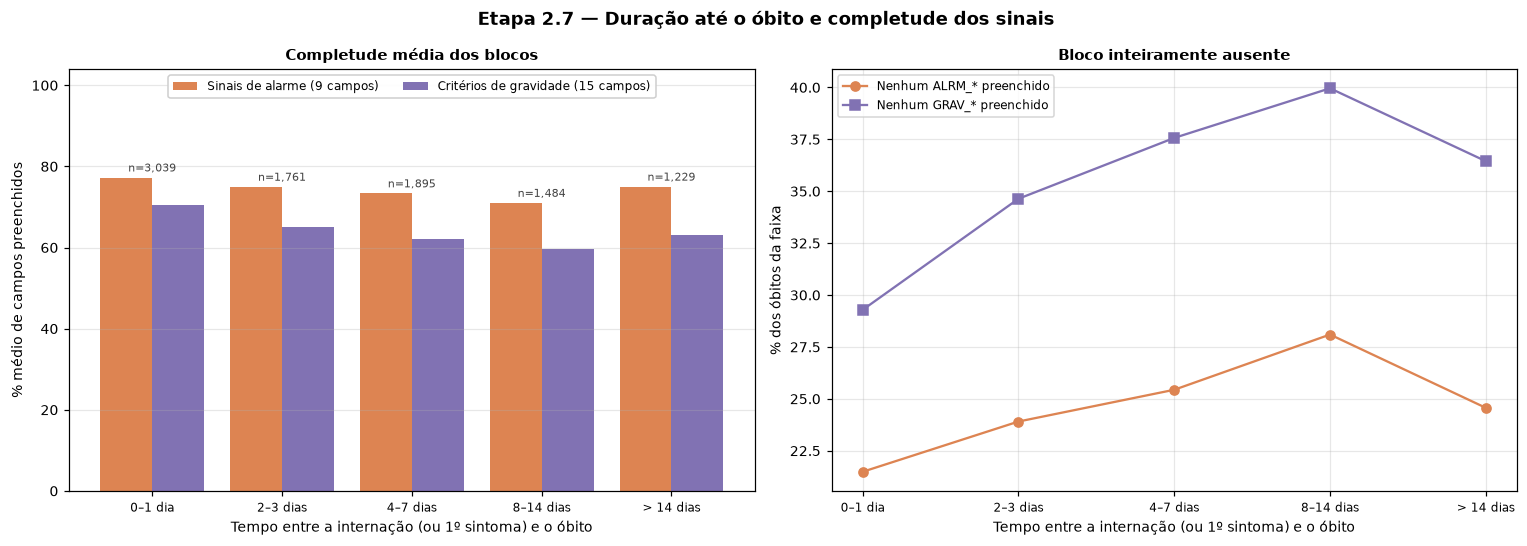

In [24]:
plot_dur = dur[~dur['faixa_duracao'].isin(['sem duração calculável', 'negativa (inconsistente)'])]
x = np.arange(len(plot_dur))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(x - 0.2, plot_dur['pct_alrm_preenchidos'], width=0.4, color=COR_ALRM, label='Sinais de alarme (9 campos)')
ax.bar(x + 0.2, plot_dur['pct_grav_preenchidos'], width=0.4, color=COR_GRAV, label='Critérios de gravidade (15 campos)')
ax.set_xticks(x); ax.set_xticklabels(plot_dur['faixa_duracao'], fontsize=8)
ax.set_ylabel('% médio de campos preenchidos')
ax.set_xlabel('Tempo entre a internação (ou 1º sintoma) e o óbito')
ax.set_title('Completude média dos blocos', fontweight='bold', fontsize=10)
ax.set_ylim(0, 104)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8, loc='upper center', ncol=2, framealpha=0.95)
for i, (_, r) in enumerate(plot_dur.iterrows()):
    ax.text(i, max(r['pct_alrm_preenchidos'], r['pct_grav_preenchidos']) + 1.5,
            f"n={int(r['n_obitos']):,}", ha='center', fontsize=7, color='#444')

ax = axes[1]
ax.plot(x, plot_dur['pct_todos_alrm_ausentes'], marker='o', color=COR_ALRM, label='Nenhum ALRM_* preenchido')
ax.plot(x, plot_dur['pct_todos_grav_ausentes'], marker='s', color=COR_GRAV, label='Nenhum GRAV_* preenchido')
ax.set_xticks(x); ax.set_xticklabels(plot_dur['faixa_duracao'], fontsize=8)
ax.set_ylabel('% dos óbitos da faixa')
ax.set_xlabel('Tempo entre a internação (ou 1º sintoma) e o óbito')
ax.set_title('Bloco inteiramente ausente', fontweight='bold', fontsize=10)
ax.grid(alpha=0.3); ax.legend(fontsize=8)

plt.suptitle('Etapa 2.7 — Duração até o óbito e completude dos sinais', fontsize=12, fontweight='bold')
plt.tight_layout()
salvar_fig(fig, 'duracao_internacao_vs_completude.png')
plt.show()

---

## Etapa 3 — Cenário contrafactual mínimo

Sem retreinar nada. No conjunto de teste (2024, com a partição de `utils/split_data.py`:
`year == 2024`, onde `year = SEM_PRI // 100`), quantos registros teriam o sinal datado **até a
notificação** (`DT_ALRM <= DT_NOTIFIC`) e quantos **até a internação** (`DT_ALRM <= DT_INTERNA`).
Cada subconjunto vai por desfecho, com a prevalência de óbito. Dimensiona o custo de uma eventual
reanálise restrita a preditores comprovadamente disponíveis em cada um desses dois momentos.

In [25]:
teste = coorte[coorte['year'].isin(split_data.TEST_YEARS)].copy()
import json as _json
with open(os.path.join(ROOT, 'data', 'features', 'baseline', 'config.json')) as f:
    cfg = _json.load(f)

print(f'Conjunto de teste reconstruido (year in {split_data.TEST_YEARS}): {len(teste):,} registros, '
      f'{int(teste["obito"].sum()):,} obitos ({teste["obito"].mean() * 100:.2f}%)')
print(f'config.json do pipeline:  test_size = {cfg["test_size"]:,} | test_events = {cfg["test_events"]:,}')
print(f'Confere? {len(teste) == cfg["test_size"] and int(teste["obito"].sum()) == cfg["test_events"]}')

Conjunto de teste reconstruido (year in [2024]): 160,302 registros, 5,292 obitos (3.30%)
config.json do pipeline:  test_size = 160,302 | test_events = 5,292
Confere? True


Classificação de cada registro do teste em sinal datado até o marco, datado após o marco, marco ausente ou sinal não datado, separadamente para a notificação e para a internação.

In [26]:
def classificar(df_, col_data, marco):
    '''Categoria temporal do registro do sinal em relacao a um marco.'''
    cat = pd.Series('sinal não datado', index=df_.index, dtype=object)
    cat[df_[col_data].notna() & df_[marco].isna()] = 'marco ausente (não ancorável)'
    ok = df_[col_data].notna() & df_[marco].notna()
    cat[ok & (df_[col_data] <= df_[marco])] = 'datado até o marco'
    cat[ok & (df_[col_data] > df_[marco])]  = 'datado após o marco'
    return cat


CATEGORIAS = ['datado até o marco', 'datado após o marco',
              'marco ausente (não ancorável)', 'sinal não datado']


def resumo_cenario(df_, col_data, marco, bloco):
    cat = classificar(df_, col_data, marco)
    g = df_.assign(categoria=cat).groupby('categoria')
    out = g.agg(n=('obito', 'size'), n_obitos=('obito', 'sum')).reset_index()
    out['n_curas'] = out['n'] - out['n_obitos']
    out['pct_do_teste'] = (out['n'] / len(df_) * 100).round(2)
    out['prevalencia_obito_pct'] = (out['n_obitos'] / out['n'] * 100).round(3)
    out['bloco'] = bloco
    out['campo_data'] = col_data
    out['marco'] = marco
    out['n_base'] = len(df_)
    out['ordem'] = out['categoria'].map({c: i for i, c in enumerate(CATEGORIAS)})
    out = out.sort_values('ordem').drop(columns='ordem')
    return out[['bloco', 'campo_data', 'marco', 'categoria', 'n', 'pct_do_teste',
                'n_curas', 'n_obitos', 'prevalencia_obito_pct', 'n_base']]


cen = pd.concat([
    resumo_cenario(teste, 'DT_ALRM', 'DT_NOTIFIC', 'Sinais de alarme (ALRM_*)'),
    resumo_cenario(teste, 'DT_ALRM', 'DT_INTERNA', 'Sinais de alarme (ALRM_*)'),
    resumo_cenario(teste, 'DT_GRAV', 'DT_NOTIFIC', 'Sinais de gravidade (GRAV_*)'),
    resumo_cenario(teste, 'DT_GRAV', 'DT_INTERNA', 'Sinais de gravidade (GRAV_*)'),
], ignore_index=True)

salvar_tab(cen, 'contrafactual_teste_2024.csv')
display(cen)

[tabela] analysis/results_temporalidade/contrafactual_teste_2024.csv  (14 linhas)


,bloco,campo_data,marco,categoria,n,pct_do_teste,n_curas,n_obitos,prevalencia_obito_pct,n_base
0,Sinais de alarme (ALRM_*),DT_ALRM,DT_NOTIFIC,datado até o marco,43657,27.23,40740,2917,6.682,160302
1,Sinais de alarme (ALRM_*),DT_ALRM,DT_NOTIFIC,datado após o marco,10401,6.49,9527,874,8.403,160302
2,Sinais de alarme (ALRM_*),DT_ALRM,DT_NOTIFIC,sinal não datado,106244,66.28,104743,1501,1.413,160302
3,Sinais de alarme (ALRM_*),DT_ALRM,DT_INTERNA,datado até o marco,47678,29.74,44691,2987,6.265,160302
4,Sinais de alarme (ALRM_*),DT_ALRM,DT_INTERNA,datado após o marco,5190,3.24,4447,743,14.316,160302
5,Sinais de alarme (ALRM_*),DT_ALRM,DT_INTERNA,marco ausente (não ancorável),1190,0.74,1129,61,5.126,160302
6,Sinais de alarme (ALRM_*),DT_ALRM,DT_INTERNA,sinal não datado,106244,66.28,104743,1501,1.413,160302
7,Sinais de gravidade (GRAV_*),DT_GRAV,DT_NOTIFIC,datado até o marco,4794,2.99,2652,2142,44.681,160302
8,Sinais de gravidade (GRAV_*),DT_GRAV,DT_NOTIFIC,datado após o marco,1793,1.12,543,1250,69.716,160302
9,Sinais de gravidade (GRAV_*),DT_GRAV,DT_NOTIFIC,sinal não datado,153715,95.89,151815,1900,1.236,160302


Visão agregada do contrafactual: por bloco e por marco, quanto do teste conserva sinal datado e qual a prevalência de óbito no subconjunto que sobrevive.

In [27]:
# Visao agregada: quanto do sinal sobreviveria a cada corte temporal
prev_global = teste['obito'].mean() * 100
linhas = []
for bloco, col in [('Sinais de alarme (ALRM_*)', 'DT_ALRM'), ('Sinais de gravidade (GRAV_*)', 'DT_GRAV')]:
    tem = teste[col].notna()
    for marco in ['DT_NOTIFIC', 'DT_INTERNA']:
        disp = tem & teste[marco].notna() & (teste[col] <= teste[marco])
        linhas.append({
            'bloco': bloco,
            'criterio': f'{col} <= {marco}',
            'n_teste': len(teste),
            'n_com_sinal_datado': int(tem.sum()),
            'pct_com_sinal_datado': round(tem.mean() * 100, 2),
            'n_disponivel_no_marco': int(disp.sum()),
            'pct_do_teste_disponivel': round(disp.mean() * 100, 2),
            'pct_dos_datados_que_sobrevivem': round(disp.sum() / tem.sum() * 100, 2) if tem.sum() else np.nan,
            'n_obitos_disponivel': int(teste.loc[disp, 'obito'].sum()),
            'pct_dos_obitos_datados_que_sobrevivem': round(
                teste.loc[disp, 'obito'].sum() / teste.loc[tem, 'obito'].sum() * 100, 2
            ) if teste.loc[tem, 'obito'].sum() else np.nan,
            'prevalencia_obito_no_subconjunto_pct': round(teste.loc[disp, 'obito'].mean() * 100, 3) if disp.sum() else np.nan,
            'prevalencia_obito_no_teste_pct': round(prev_global, 3),
        })

cen_agg = pd.DataFrame(linhas)
salvar_tab(cen_agg, 'contrafactual_teste_2024_agregado.csv')
display(cen_agg)

[tabela] analysis/results_temporalidade/contrafactual_teste_2024_agregado.csv  (4 linhas)


,bloco,criterio,n_teste,n_com_sinal_datado,pct_com_sinal_datado,n_disponivel_no_marco,pct_do_teste_disponivel,pct_dos_datados_que_sobrevivem,n_obitos_disponivel,pct_dos_obitos_datados_que_sobrevivem,prevalencia_obito_no_subconjunto_pct,prevalencia_obito_no_teste_pct
0,Sinais de alarme (ALRM_*),DT_ALRM <= DT_NOTIFIC,160302,54058,33.72,43657,27.23,80.76,2917,76.95,6.682,3.301
1,Sinais de alarme (ALRM_*),DT_ALRM <= DT_INTERNA,160302,54058,33.72,47678,29.74,88.20,2987,78.79,6.265,3.301
2,Sinais de gravidade (GRAV_*),DT_GRAV <= DT_NOTIFIC,160302,6587,4.11,4794,2.99,72.78,2142,63.15,44.681,3.301
3,Sinais de gravidade (GRAV_*),DT_GRAV <= DT_INTERNA,160302,6587,4.11,4691,2.93,71.22,2010,59.26,42.848,3.301


Figura do contrafactual: quanto do sinal sobrevive a cada corte temporal, por bloco e por marco, com a prevalência de óbito de cada subconjunto.

[figura] analysis/plots/temporalidade/contrafactual_teste_2024.png


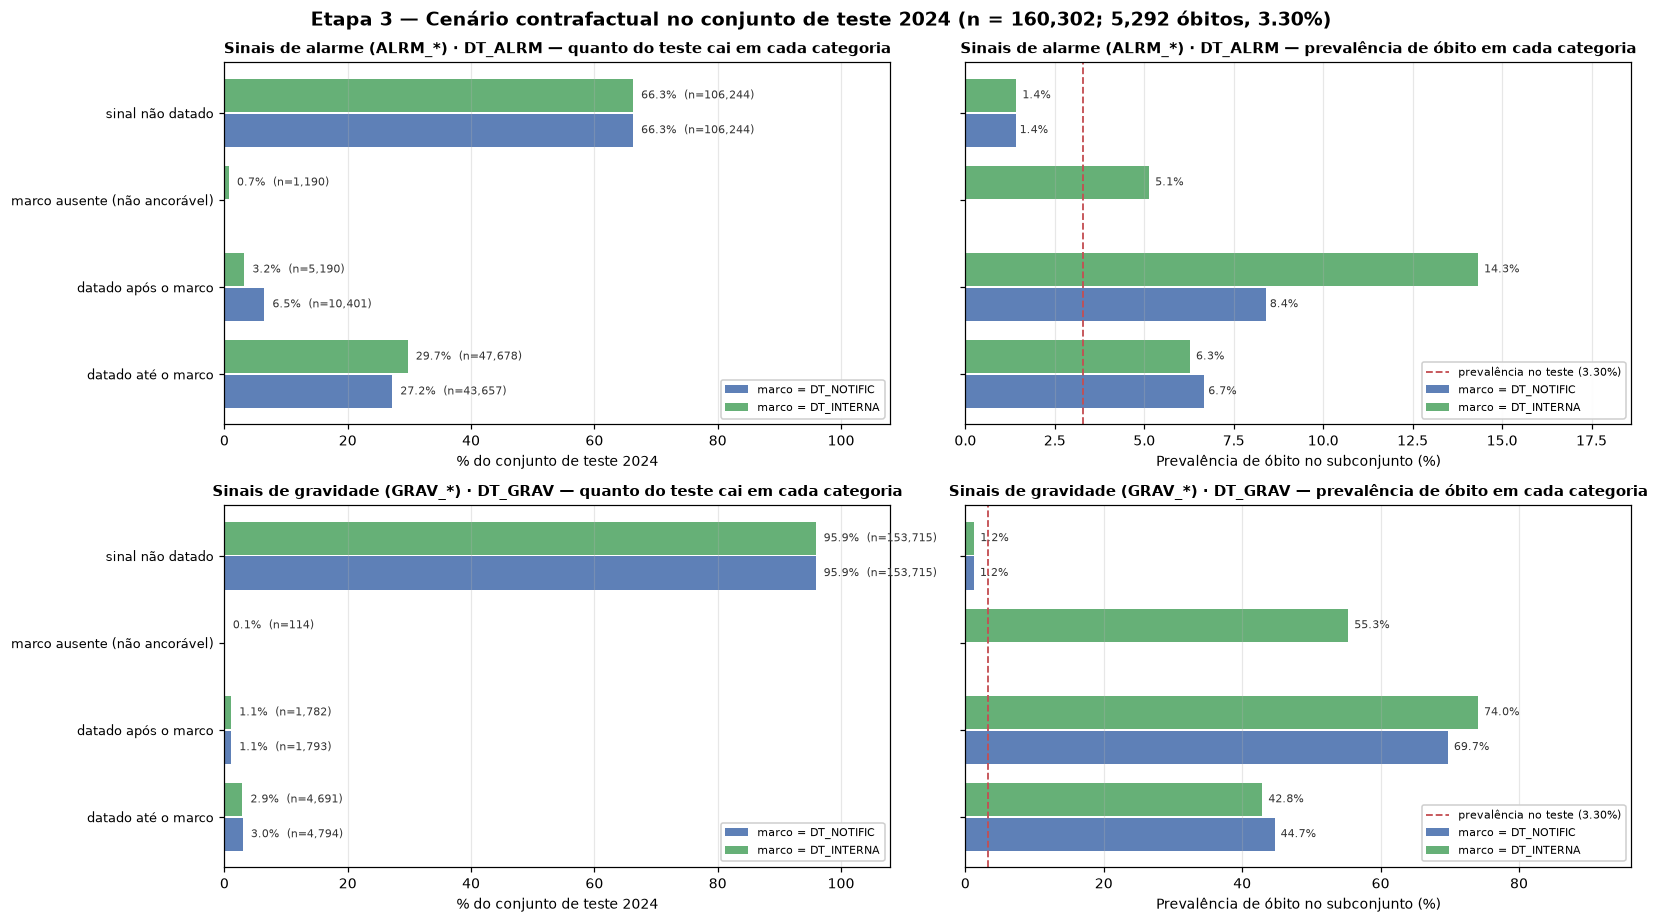

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8.5), sharey='row')

CORES_MARCO = {'DT_NOTIFIC': '#4C72B0', 'DT_INTERNA': '#55A868'}
blocos = [('Sinais de alarme (ALRM_*)', 'DT_ALRM'), ('Sinais de gravidade (GRAV_*)', 'DT_GRAV')]

for linha, (bloco, col) in enumerate(blocos):
    sub = cen[cen['bloco'] == bloco]
    y = np.arange(len(CATEGORIAS))

    for painel, (campo, rotulo_x, limite, sub_titulo) in enumerate([
            ('pct_do_teste', '% do conjunto de teste 2024', 108, 'quanto do teste cai em cada categoria'),
            ('prevalencia_obito_pct', 'Prevalência de óbito no subconjunto (%)', None,
             'prevalência de óbito em cada categoria')]):
        ax = axes[linha][painel]
        for k, marco in enumerate(['DT_NOTIFIC', 'DT_INTERNA']):
            s = sub[sub['marco'] == marco].set_index('categoria').reindex(CATEGORIAS)
            vals = s[campo].fillna(0).to_numpy()
            barras = ax.barh(y + (0.2 if k else -0.2), vals, height=0.38,
                             color=CORES_MARCO[marco], alpha=0.9,
                             label=f'marco = {marco}')
            for b_, v, n_ in zip(barras, vals, s['n'].fillna(0).to_numpy()):
                if v <= 0:
                    continue
                texto = f'{v:.1f}%' + (f'  (n={int(n_):,})' if painel == 0 else '')
                ax.text(v + (limite or max(vals) * 1.05) * 0.012,
                        b_.get_y() + b_.get_height() / 2, texto,
                        va='center', fontsize=7.5, color='#333')

        if painel == 1:
            ax.axvline(prev_global, color=COR_OBITO, ls='--', lw=1.2,
                       label=f'prevalência no teste ({prev_global:.2f}%)')
        ax.set_yticks(y)
        ax.set_yticklabels(CATEGORIAS, fontsize=8.5)
        ax.invert_yaxis()
        ax.set_xlabel(rotulo_x, fontsize=9)
        if limite:
            ax.set_xlim(0, limite)
        else:
            ax.set_xlim(0, max(sub['prevalencia_obito_pct'].max() * 1.3, 5))
        ax.grid(axis='x', alpha=0.3)
        ax.set_title(f'{bloco} · {col} — {sub_titulo}', fontweight='bold', fontsize=9.5)
        ax.legend(fontsize=7.5, loc='lower right', framealpha=0.95)

plt.suptitle(f'Etapa 3 — Cenário contrafactual no conjunto de teste 2024 '
             f'(n = {len(teste):,}; {int(teste["obito"].sum()):,} óbitos, {prev_global:.2f}%)',
             fontsize=12.5, fontweight='bold')
plt.tight_layout()
salvar_fig(fig, 'contrafactual_teste_2024.png')
plt.show()

## Conclusões

- A coorte reconstruída tem 350.850 registros e 9.451 óbitos, 2,7% de letalidade, e confere com `dengue_hospitalized.parquet` e com `dengue_treated.parquet`.
  Nenhum arquivo do repositório, na extração atual, produz os 361.548 registros de referência: a diferença é de 10.698 registros.

- A restrição a internados é o filtro dominante: dos 10.302.973 casos confirmados com desfecho conhecido, 350.850 são internados, de modo que a coorte analítica é 3,4% do universo confirmado.

- As duas datas centrais são pouco preenchidas na coorte e muito preenchidas nos óbitos.
  `DT_ALRM` está em 30,5% da coorte e em 72,2% dos óbitos; `DT_GRAV`, em 3,5% e 65,1%.

- A completude depende do desfecho em todos os campos que não são de preenchimento obrigatório.
  `DT_GRAV` está em 1,8% das curas contra 65,1% dos óbitos, uma razão de 36,0 vezes, e `DT_ALRM` em 29,3% contra 72,2%, razão de 2,5 vezes.

- Parte do sinal é datada depois do marco em que a ficha foi aberta.
  Em relação à notificação, 19,1% dos registros com `DT_ALRM` e 26,4% dos com `DT_GRAV` têm defasagem positiva; entre os óbitos, 22,0% e 35,6%.
  Em relação à internação, 10,4% e 28,1% no total, e 20,0% e 39,4% entre os óbitos.

- A ancoragem na internação não existe para parte da coorte: 46.607 internados, 13,3%, não têm `DT_INTERNA`, proporção que é de 13,6% entre as curas e 2,6% entre os óbitos.

- O indicador mais direto de vazamento temporal é o sinal datado no dia do óbito ou depois dele.
  Ocorre em 13,6% dos óbitos com `DT_ALRM`, 928 registros, e em 26,7% dos com `DT_GRAV`, 1.645 registros.
  Estritamente depois do óbito são 141 e 183 registros.
  A defasagem mediana entre o óbito e o registro do sinal é de 3 dias para o alarme e 2 dias para a gravidade.

- A ficha é consolidada na investigação, e não na notificação.
  `DT_ENCERRA − DT_NOTIFIC` tem mediana de 13 dias no total e 29 dias nos óbitos, e `DT_DIGITA − DT_NOTIFIC`, mediana de 4 dias.
  `DT_INVEST` coincide com `DT_NOTIFIC` em 94,0% dos registros, o que a caracteriza como preenchimento automático e não como marco temporal utilizável.

- A ausência campo a campo depende do desfecho de forma uniforme dentro de cada bloco.
  Nos 15 critérios de gravidade a ausência é de cerca de 98,2% nas curas contra cerca de 35,0% nos óbitos; nos 9 sinais de alarme, cerca de 70,5% contra cerca de 25,2%.
  Esta é a evidência que não depende de `DT_ALRM` e `DT_GRAV` estarem preenchidas.

- A hipótese de que óbitos rápidos teriam mais ausências não se sustenta, e o padrão observado é o inverso.
  A proporção de óbitos com todos os critérios de gravidade ausentes é de 29,3% na faixa de 0 a 1 dia e sobe para 40,0% na faixa de 8 a 14 dias.

- Um corte temporal removeria a maior parte do sinal.
  Restringir os sinais de alarme ao que foi datado até a notificação preserva 27,2% do teste de 2024, e até a internação, 29,7%.
  Para os critérios de gravidade, 3,0% e 2,9%.
  Os subconjuntos que sobrevivem são fortemente selecionados: a prevalência de óbito neles é de 6,7% e 44,7%, contra 3,3% no teste completo.

- A qualidade das datas não compromete a leitura: 8 valores falharam na conversão entre todos os presentes, 0,0003%.
  As ordenações impossíveis são pouco frequentes e de magnitude semelhante entre campos: `DT_ALRM < DT_SIN_PRI` em 2,4% dos registros com ambas as datas, `DT_INTERNA < DT_SIN_PRI` em 2,3% e `DT_GRAV < DT_SIN_PRI` em 2,1%.

- As datas são consistentes com os campos que datam: entre os registros com pelo menos um sinal de alarme presente, 99,0% têm `DT_ALRM`, e entre os com pelo menos um critério de gravidade presente, 99,0% têm `DT_GRAV`.

- Ressalva que vale para toda a análise de defasagem: ela se restringe aos registros com a data preenchida, que são um subconjunto seletivo, formado pelos casos em que o sinal foi de fato registrado. O N de base acompanha cada tabela.